# Import libraries

In [5]:
import numpy as np
import pandas as pd 

### Data loading

In [6]:
# For SKUs starting with '90'
# Data loading
df = pd.read_csv('data/ForecastDataset_from_2016_to_2025_for_SKUs_started_with_90.csv')

In [7]:
df.head(-1)

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState
0,AIRD,62181848,12/19/2022,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA
1,AIRD,60849149,7/8/2021,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA
2,AIRD,60849335,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR
3,AIRD,60849349,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT
4,AIRD,60849449,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD
...,...,...,...,...,...,...,...,...,...
533942,AIRD,698996,7/25/2025,Air Doctor AD2000,1,90AD200AD01,Unit,Main,TX
533943,AIRD,691953,7/19/2025,Air Doctor AD3500,1,90AD350AD01,Unit,TRN_DRTESF,WV
533944,AIRD,697528,7/24/2025,Air Doctor AD5500,1,90AD550AD01,Unit,Main,IA
533945,AIRD,700439,7/25/2025,Air Doctor AD2000,1,90AD200AD01,Unit,email,CA


In [8]:
df.shape

(533948, 9)

In [9]:
df.columns

Index(['ProductFamily', 'Order_ID', 'OrderDate', 'SKU_Description',
       'WareHouseQuantity', 'SKU', 'SKU_Category', 'Channel', 'ShipToState'],
      dtype='object')

In [10]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState
0,AIRD,62181848,12/19/2022,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA
1,AIRD,60849149,7/8/2021,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA
2,AIRD,60849335,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR
3,AIRD,60849349,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT
4,AIRD,60849449,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD


In [11]:
df.nunique()

ProductFamily             1
Order_ID             479881
OrderDate              3103
SKU_Description          20
WareHouseQuantity        13
SKU                      21
SKU_Category              3
Channel                  34
ShipToState              88
dtype: int64

In [12]:
df.isna().sum()

ProductFamily          0
Order_ID               0
OrderDate              0
SKU_Description      544
WareHouseQuantity      0
SKU                    0
SKU_Category         544
Channel               12
ShipToState           92
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.shape

(533300, 9)

In [15]:
df.head()

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState
0,AIRD,62181848,12/19/2022,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA
1,AIRD,60849149,7/8/2021,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA
2,AIRD,60849335,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR
3,AIRD,60849349,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT
4,AIRD,60849449,7/8/2021,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD


### Feature Engineering

In [20]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
df['Month'] = df['OrderDate'].dt.month
df['Year'] = df['OrderDate'].dt.year

In [21]:
df.head(-1)

,ProductFamily,Order_ID,OrderDate,SKU_Description,WareHouseQuantity,SKU,SKU_Category,Channel,ShipToState,Week,Month,Year
0,AIRD,62181848,2022-12-19,Air Doctor AD3000,1,90AD01AD01,Cross Sell,SEM_Radial,VA,2022-12-19,12,2022
1,AIRD,60849149,2021-07-08,Air Doctor AD1000 Tower,1,90AD01AT01-W,Unit,DIG_OTHER_Radial,PA,2021-07-05,7,2021
2,AIRD,60849335,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,OR,2021-07-05,7,2021
3,AIRD,60849349,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,WEB_Radial,MT,2021-07-05,7,2021
4,AIRD,60849449,2021-07-08,Air Doctor AD3000,1,90AD01AD01,Cross Sell,DIG_INFLCR_Radial,MD,2021-07-05,7,2021
...,...,...,...,...,...,...,...,...,...,...,...,...
533942,AIRD,698996,2025-07-25,Air Doctor AD2000,1,90AD200AD01,Unit,Main,TX,2025-07-21,7,2025
533943,AIRD,691953,2025-07-19,Air Doctor AD3500,1,90AD350AD01,Unit,TRN_DRTESF,WV,2025-07-14,7,2025
533944,AIRD,697528,2025-07-24,Air Doctor AD5500,1,90AD550AD01,Unit,Main,IA,2025-07-21,7,2025
533945,AIRD,700439,2025-07-25,Air Doctor AD2000,1,90AD200AD01,Unit,email,CA,2025-07-21,7,2025


### Weekly Sales Trend

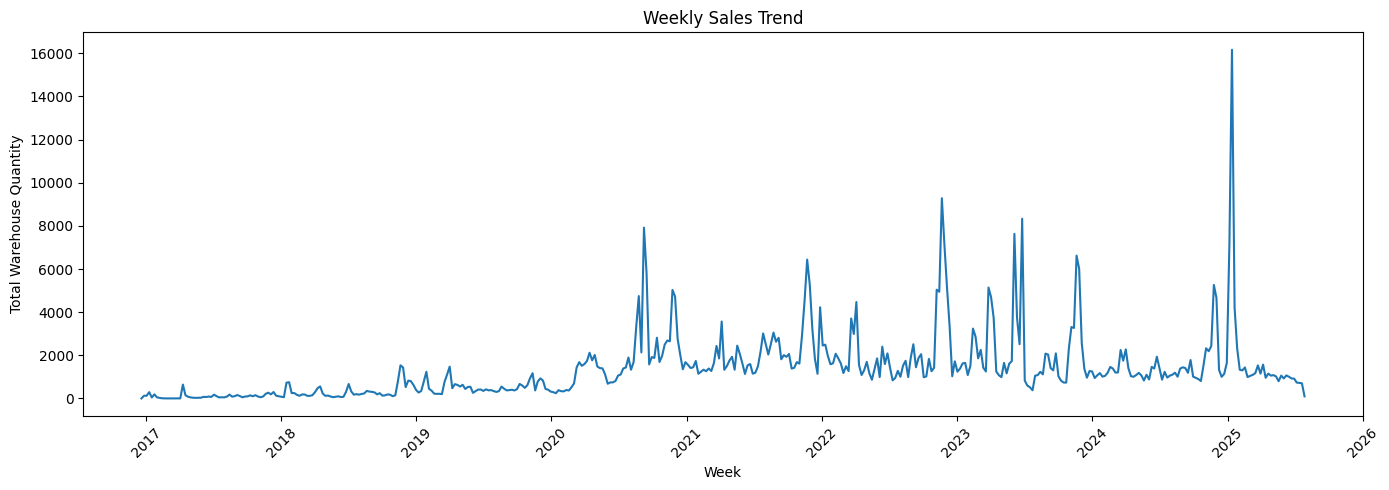

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

weekly_trend = df.groupby('Week')['WareHouseQuantity'].sum().reset_index()

plt.figure(figsize=(14, 5))
sns.lineplot(data=weekly_trend, x='Week', y='WareHouseQuantity')
plt.title("Weekly Sales Trend")
plt.xlabel("Week")
plt.ylabel("Total Warehouse Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### WareHouseQuantity By Channel

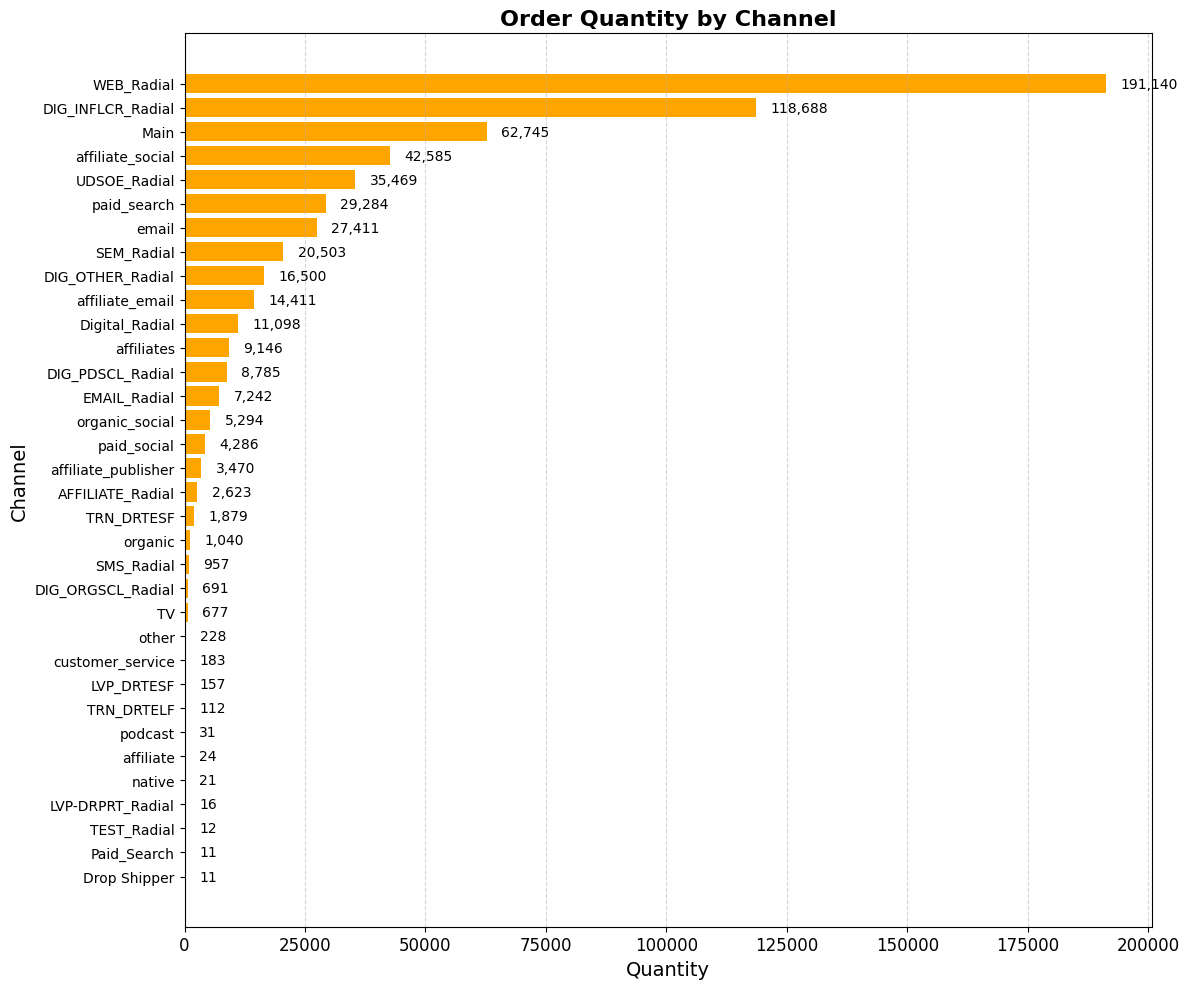

In [23]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate and sort
channel_orders = df.groupby('Channel')['WareHouseQuantity'].sum().sort_values(ascending=True)

# Increase figure size
plt.figure(figsize=(12, 10))

# Plot
bars = plt.barh(channel_orders.index, channel_orders.values, color='orange')

# Title and axis labels
plt.title('Order Quantity by Channel', fontsize=16, fontweight='bold')
plt.xlabel('Quantity', fontsize=14)
plt.ylabel('Channel', fontsize=14)

# Add quantity labels to each bar
for bar in bars:
    width = bar.get_width()
    plt.text(width + 3000,               # offset to the right
             bar.get_y() + bar.get_height()/2,
             f'{int(width):,}',          # format with comma
             va='center', fontsize=10, color='black')

# Improve layout
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.xticks(fontsize=12)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


In [24]:
df['Channel'].value_counts()

Channel
WEB_Radial             163270
DIG_INFLCR_Radial      107149
Main                    49774
affiliate_social        37890
UDSOE_Radial            29270
paid_search             25938
email                   24433
SEM_Radial              18187
DIG_OTHER_Radial        14326
affiliate_email         12779
Digital_Radial           8790
affiliates               8025
DIG_PDSCL_Radial         7695
EMAIL_Radial             6434
organic_social           4652
paid_social              3814
affiliate_publisher      3000
AFFILIATE_Radial         2329
TRN_DRTESF               1828
organic                   925
SMS_Radial                749
TV                        671
DIG_ORGSCL_Radial         624
other                     228
customer_service          158
LVP_DRTESF                146
TRN_DRTELF                102
podcast                    27
affiliate                  21
native                     20
LVP-DRPRT_Radial           15
Drop Shipper               11
Paid_Search                11
TE

### Top SKU

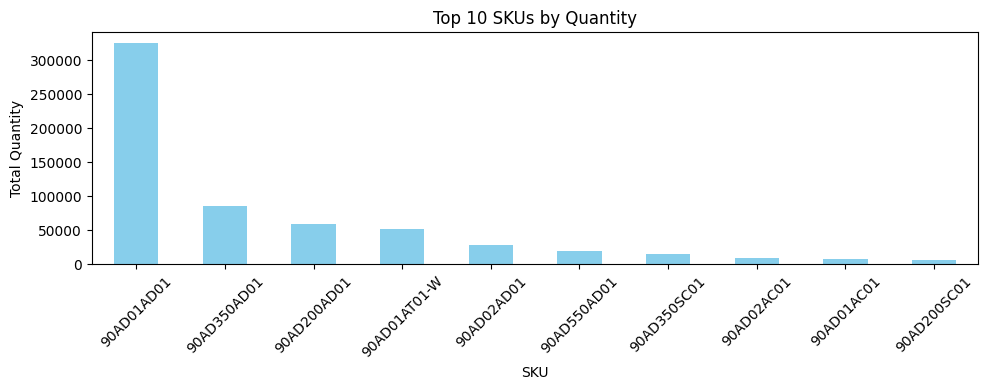

In [25]:
top_skus = df.groupby('SKU')['WareHouseQuantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 4))
top_skus.plot(kind='bar', color='skyblue')
plt.title("Top 10 SKUs by Quantity")
plt.ylabel("Total Quantity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [26]:
top_skus        # 90AD350AD01

SKU
90AD01AD01      324507
90AD350AD01      85374
90AD200AD01      59234
90AD01AT01-W     51522
90AD02AD01       28398
90AD550AD01      19563
90AD350SC01      14795
90AD02AC01        8737
90AD01AC01        8460
90AD200SC01       6213
Name: WareHouseQuantity, dtype: int64

### Range Of SKU's

In [27]:
def print_date_ranges(df, sku_list=None):
    """
    Prints the overall dataset date range and individual date ranges for specified SKUs.

    Parameters:
    df (pd.DataFrame): DataFrame containing at least 'OrderDate' and 'SKU' columns.
    sku_list (list, optional): List of SKU strings to check date ranges for.
    """
    print("Full dataset date range:", df['OrderDate'].min(), "to", df['OrderDate'].max())
    
    if sku_list:
        for sku in sku_list:
            df_sku_check = df[df['SKU'] == sku]
            if not df_sku_check.empty:
                print(f"Selected SKU date range {sku}:", df_sku_check['OrderDate'].min(), "to", df_sku_check['OrderDate'].max())
                # print(f"Total weekly data points for this SKU: {df_sku_check.shape[0]}")
            else:
                print(f"No data found for SKU: {sku}")
                


In [28]:
sku_list = ['90AD350AD01', '90AD200AD01', '90AD01AT01-W', '90AD02AD01', '90AD550AD01']
print_date_ranges(df, sku_list)


Full dataset date range: 2016-12-23 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD350AD01: 2022-09-15 00:00:00 to 2025-07-29 00:00:00
Selected SKU date range 90AD200AD01: 2022-06-04 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD01AT01-W: 2019-08-16 00:00:00 to 2025-07-28 00:00:00
Selected SKU date range 90AD02AD01: 2021-05-25 00:00:00 to 2023-06-30 00:00:00
Selected SKU date range 90AD550AD01: 2022-09-15 00:00:00 to 2025-07-28 00:00:00


### Data Splitting: Training and Testing (For Checking Accuracy)
- For Testing : April, May, June 2025
- For Training : Sep 22 to March 31

In [29]:
import pandas as pd
from dateutil.relativedelta import relativedelta


# Convert OrderDate to datetime
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

# Create 'Week' column as week start date (Monday)
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)

# Group weekly by SKU
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

# Filter for the specific SKU
sku = '90AD350AD01'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()

# Add week start and end dates
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# -----------------------
# Split Test & Train
# -----------------------

# Test Data: April, May, June 2025
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2025-04-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2025-07-01'))
]

# Train Data: Before April 2025
train_data = df_sku_weekly[
    df_sku_weekly['Week_Start'] < pd.to_datetime('2025-04-01')
]


# -----------------------
# TRAIN DATA RANGE INFO
# -----------------------
# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")


print("\nTrain Data:")
print(train_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))

print("\nTest Data:")
print(test_data[['Week_Start', 'Week_End', 'WareHouseQuantity']].head(-1))




Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13

Train Data:
     Week_Start   Week_End  WareHouseQuantity
786  2022-09-12 2022-09-18                  1
801  2022-09-26 2022-10-02                  5
821  2022-10-17 2022-10-23                 17
831  2022-10-24 2022-10-30                 84
842  2022-10-31 2022-11-06                125
...         ...        ...                ...
1891 2025-02-24 2025-03-02                398
1902 2025-03-03 2025-03-09                447
1912 2025-03-10 2025-03-16                482
1922 2025-03-17 2025-03-23                596
1931 2025-03-24 2025-03-30                721

[130 rows x 3 columns]

Test Data:
     Week_Start   Week_End  WareHouseQuantity
1950 2025-04-07 2025-04-13                738
1959 2025-04-14 2025-04-20                432
1968 2025-04-21 2025-04-27                541
197

In [30]:
# # Save training and testing data to CSV
# train_data[['Week_Start', 'Week_End', 'WareHouseQuanity']].to_csv('training_data.csv', index=False)
# test_data[['Week_Start', 'Week_End', 'WareHouseQuanity']].to_csv('testing_data.csv', index=False)

# print("Files saved successfully.")


### For Continuous Values(Default)

11:12:37 - cmdstanpy - INFO - Chain [1] start processing



Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


11:12:37 - cmdstanpy - INFO - Chain [1] done processing


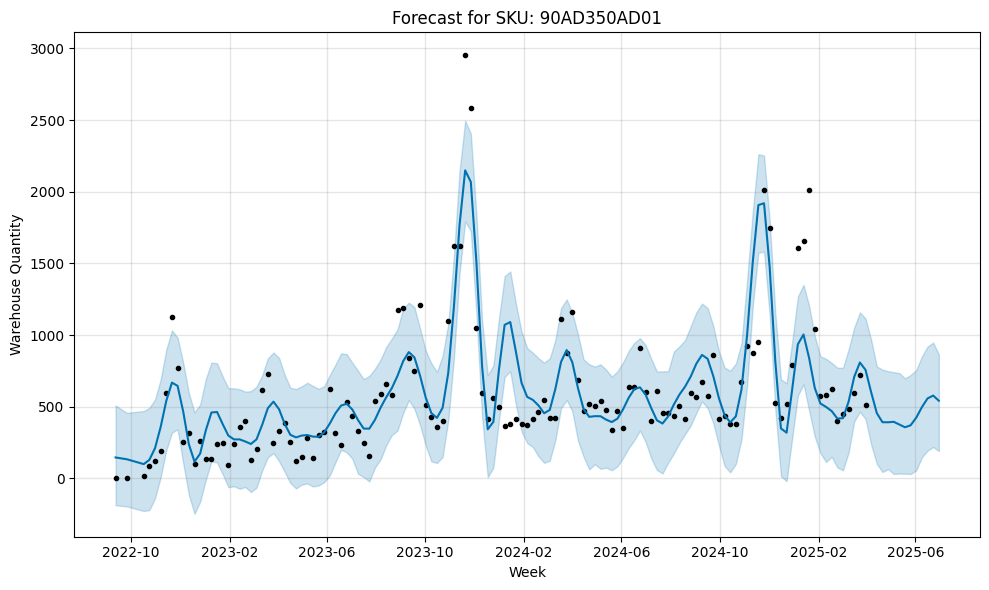

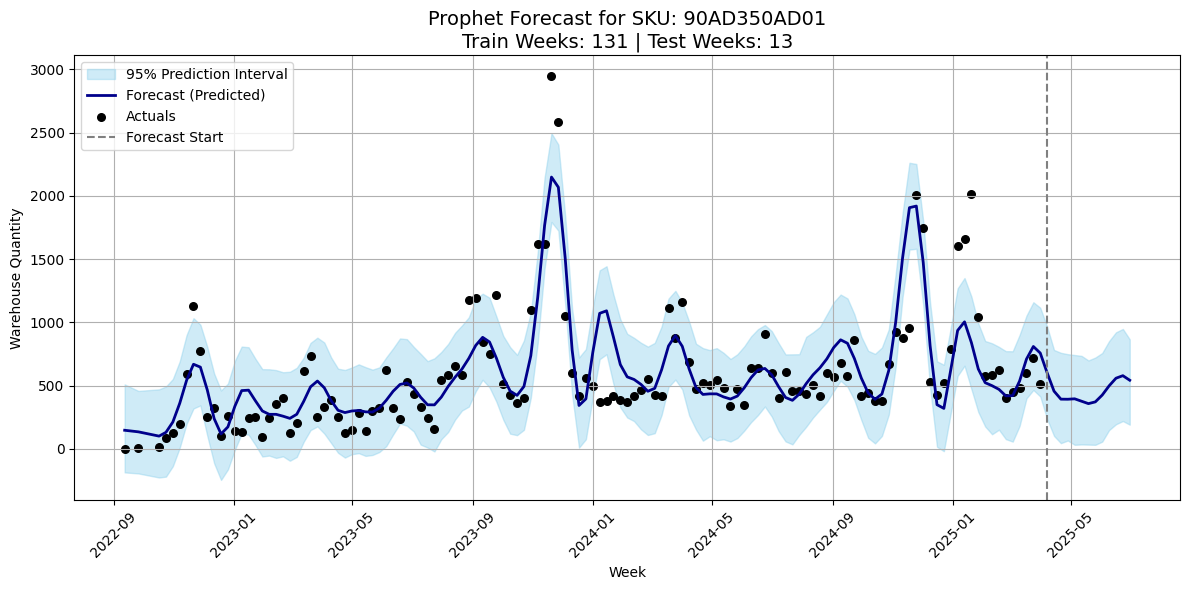


Forecast vs Actuals (January to April 2024):
            ds  WareHouseQuantity        yhat
131 2025-04-07              738.0  600.946985
132 2025-04-14              432.0  455.748609
133 2025-04-21              541.0  392.347527
134 2025-04-28              509.0  391.673642
135 2025-05-05              506.0  395.013050
136 2025-05-12              486.0  376.005405
137 2025-05-19              318.0  356.939124
138 2025-05-26              414.0  370.796066
139 2025-06-02              375.0  424.599145
140 2025-06-09              474.0  497.417951
141 2025-06-16              475.0  557.998915
142 2025-06-23              390.0  578.054631
143 2025-06-30              388.0  541.943914

Accuracy Metrics:
MAE  (Mean Absolute Error):        94.46
MSE  (Mean Squared Error):         11690.07
RMSE (Root Mean Squared Error):    108.12
MAPE (Mean Absolute % Error):      20.41%
R²   (R-squared Score):            -0.17


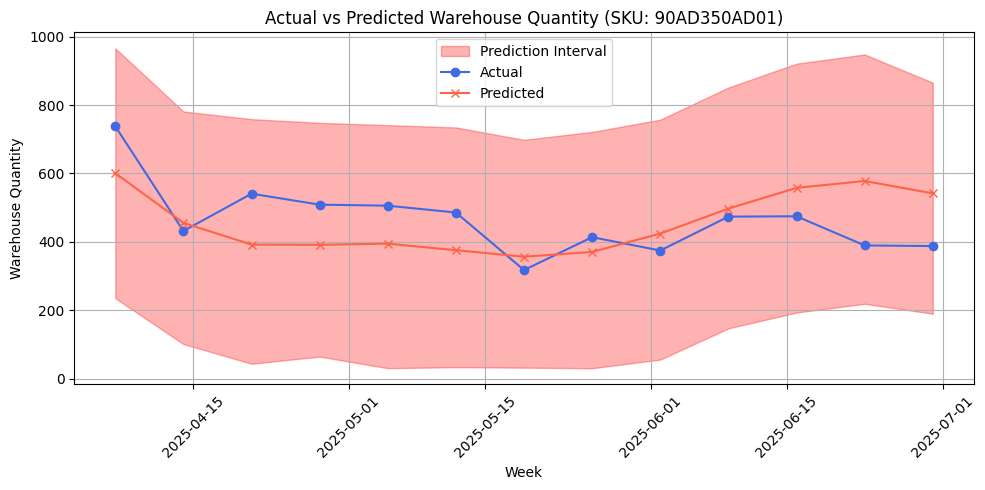


Final Forecast Results with Percent Difference:


,Start_Week,End_Week,Actual_WareHouseQuanity,Predicted_WareHouseQuanity,Difference_Between_Predicted_And_Actual,Percent_Difference
131,2025-04-07,2025-04-13,738.0,600.946985,-137.053015,-18.57%
132,2025-04-14,2025-04-20,432.0,455.748609,23.748609,5.5%
133,2025-04-21,2025-04-27,541.0,392.347527,-148.652473,-27.48%
134,2025-04-28,2025-05-04,509.0,391.673642,-117.326358,-23.05%
135,2025-05-05,2025-05-11,506.0,395.013050,-110.986950,-21.93%
136,2025-05-12,2025-05-18,486.0,376.005405,-109.994595,-22.63%
137,2025-05-19,2025-05-25,318.0,356.939124,38.939124,12.25%
138,2025-05-26,2025-06-01,414.0,370.796066,-43.203934,-10.44%
139,2025-06-02,2025-06-08,375.0,424.599145,49.599145,13.23%
140,2025-06-09,2025-06-15,474.0,497.417951,23.417951,4.94%


In [65]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    # growth='linear',
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.1,
    seasonality_prior_scale=1.0,
    holidays_prior_scale=0.0016039844171628211
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)


# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval(Using Prophet default)
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Updated): Enhanced Forecast Plot

# Extract historical actuals
historical = prophet_df.copy()
historical['label'] = 'Actuals'

# Prepare forecast line
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

# Plot setup
plt.figure(figsize=(12, 6))

# Confidence interval
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')

# Forecast line
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)

# Actuals as scatter points
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

# Vertical line for training-test boundary
test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

# Title with time span info
plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# STEP 6: Merge actual test data for comparison
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actual
print("\nForecast vs Actuals (January to April 2024):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuantity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()

# Rename columns
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)

# Drop missing
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

# Metrics
y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted with interval
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Create final result DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']

# New: Add Percent Difference column
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Create final result
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuanity',
    'predicted': 'Predicted_WareHouseQuanity'
}, inplace=True)

# Round and add percent sign
final_result['Percent_Difference'] = final_result['Percent_Difference'].round(2).astype(str) + '%'



# Optional: Save to CSV
# final_result.to_csv("actual_vs_predicted_forecast_results.csv", index=False)

# Print final result
print("\nFinal Forecast Results with Percent Difference:")
final_result


In [79]:
train_data

,Week,WareHouseQuantity,Week_Start,Week_End
786,2022-09-12,1,2022-09-12,2022-09-18
801,2022-09-26,5,2022-09-26,2022-10-02
821,2022-10-17,17,2022-10-17,2022-10-23
831,2022-10-24,84,2022-10-24,2022-10-30
842,2022-10-31,125,2022-10-31,2022-11-06
...,...,...,...,...
1902,2025-03-03,447,2025-03-03,2025-03-09
1912,2025-03-10,482,2025-03-10,2025-03-16
1922,2025-03-17,596,2025-03-17,2025-03-23
1931,2025-03-24,721,2025-03-24,2025-03-30


### Hyperparameter Tuning

In [66]:
import pandas as pd
from prophet import Prophet
import optuna
from sklearn.metrics import mean_absolute_error

# ----------------------------
# Prepare data
# ----------------------------
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

# Filter specific SKU
sku = '90AD350AD01'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

# Split train/test
# Test Data: April, May, June 2025
test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2025-04-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2025-07-01'))
]

# Train Data: Before April 2025
train_data = df_sku_weekly[
    df_sku_weekly['Week_Start'] < pd.to_datetime('2025-04-01')
]

# Prophet format
train_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'})
test_df = test_data[['Week_Start', 'WareHouseQuantity']].rename(columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'})

# ----------------------------
# Define objective function
# ----------------------------
def objective(trial):
    params = {
        'changepoint_prior_scale': trial.suggest_categorical('changepoint_prior_scale', [0.0001, 0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]),
        'seasonality_prior_scale': trial.suggest_categorical('seasonality_prior_scale', [1.0, 5.0, 10.0, 15.0, 20.0,40.0, 50.0]),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
        'growth': 'linear',
        'weekly_seasonality': trial.suggest_categorical('weekly_seasonality', [True, False]),
        'yearly_seasonality': trial.suggest_categorical('yearly_seasonality', [True, False]),
        'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.001, 0.1, log=True),
        'daily_seasonality': False,
    }

    model = Prophet(**params)

    # Optional: Add US holidays
    model.add_country_holidays(country_name='US')

    model.fit(train_df)

    future = model.make_future_dataframe(periods=len(test_df), freq='W-MON')
    forecast = model.predict(future)

    forecast_trim = forecast.set_index('ds').loc[test_df['ds']]

    if forecast_trim.empty or len(forecast_trim) != len(test_df):
        raise ValueError("Forecast does not align with test set")

    mae = mean_absolute_error(test_df['y'].values, forecast_trim['yhat'].values)
    return mae

# ----------------------------
# Run optimization
# ----------------------------
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

# ----------------------------
# Best result
# ----------------------------
print("Best Parameters:", study.best_params)
print("Best MAE:", study.best_value)


[I 2025-08-01 11:12:53,432] A new study created in memory with name: no-name-3d9c5726-3e1b-40ae-ab96-7ce3170dffec
11:12:53 - cmdstanpy - INFO - Chain [1] start processing
11:12:53 - cmdstanpy - INFO - Chain [1] done processing
11:12:53 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
11:12:53 - cmdstanpy - INFO - Chain [1] start processing
11:12:56 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-08-01 11:12:56,629] Trial 0 finished with value: 501.4069816528208 and parameters: {'changepoint_prior_scale': 0.0001, 'seasonality_prior_scale': 50.0, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': False, 'holidays_prior_scale': 0.03225077254290006}. Best is trial 0 with value: 501.4069816528208.
11:12:56 - cmdstanpy - INFO - Chain [1] start processing
11:12:56 - cmdstanpy - INFO - Chain [1] done processing
[I 2025-08-01 11:12:56,918] Trial 1 finishe

Best Parameters: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative', 'weekly_seasonality': True, 'yearly_seasonality': True, 'holidays_prior_scale': 0.0011063293955047681}
Best MAE: 94.25315596717861


In [67]:
import pandas as pd
from prophet import Prophet
import optuna
from sklearn.metrics import mean_absolute_error

# ----------------------------
# Prepare data
# ----------------------------
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Week'] = df['OrderDate'].dt.to_period('W').apply(lambda r: r.start_time)
weekly_by_sku = df.groupby(['Week', 'SKU'])['WareHouseQuantity'].sum().reset_index()

sku = '90AD350AD01'
df_sku_weekly = weekly_by_sku[weekly_by_sku['SKU'] == sku][['Week', 'WareHouseQuantity']].copy()
df_sku_weekly['Week_Start'] = df_sku_weekly['Week']
df_sku_weekly['Week_End'] = df_sku_weekly['Week_Start'] + pd.Timedelta(days=6)

test_data = df_sku_weekly[
    (df_sku_weekly['Week_Start'] >= pd.to_datetime('2025-04-01')) &
    (df_sku_weekly['Week_Start'] < pd.to_datetime('2025-07-01'))
]
train_data = df_sku_weekly[
    df_sku_weekly['Week_Start'] < pd.to_datetime('2025-04-01')
]

train_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'})
test_df = test_data[['Week_Start', 'WareHouseQuantity']].rename(columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'})

# ----------------------------
# Define objective function
# ----------------------------
def objective(trial):
    params = {
        'changepoint_prior_scale': trial.suggest_float('changepoint_prior_scale', 0.0001, 0.5, log=True),
        'seasonality_prior_scale': trial.suggest_float('seasonality_prior_scale', 0.01, 50.0, log=True),
        'holidays_prior_scale': trial.suggest_float('holidays_prior_scale', 0.001, 10.0, log=True),
        'seasonality_mode': trial.suggest_categorical('seasonality_mode', ['additive', 'multiplicative']),
        'changepoint_range': trial.suggest_float('changepoint_range', 0.6, 0.95),
        'n_changepoints': trial.suggest_int('n_changepoints', 10, 50),
        'growth': trial.suggest_categorical('growth', ['linear', 'flat']),
        'weekly_seasonality': trial.suggest_categorical('weekly_seasonality', [True, False]),
        'yearly_seasonality': trial.suggest_categorical('yearly_seasonality', [True, False]),
        'daily_seasonality': trial.suggest_categorical('daily_seasonality', [False]),  # Weekly data
        'interval_width': trial.suggest_float('interval_width', 0.8, 0.99),
        'uncertainty_samples': trial.suggest_int('uncertainty_samples', 500, 1000)
    }

    model = Prophet(**params)
    model.add_country_holidays(country_name='US')

    try:
        model.fit(train_df)

        future = model.make_future_dataframe(periods=len(test_df), freq='W-MON')
        forecast = model.predict(future)

        forecast_trim = forecast.set_index('ds').loc[test_df['ds']]
        if forecast_trim.empty or len(forecast_trim) != len(test_df):
            raise ValueError("Forecast does not align with test set")

        mae = mean_absolute_error(test_df['y'].values, forecast_trim['yhat'].values)
        return mae
    except Exception as e:
        return float('inf')  # Penalize failed trials

# ----------------------------
# Run optimization
# ----------------------------
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=500, show_progress_bar=True)

# ----------------------------
# Best result
# ----------------------------
print("Best Parameters:", study.best_params)
print("Best MAE:", study.best_value)


[I 2025-08-01 11:13:56,464] A new study created in memory with name: no-name-5882f2bf-c11d-41a3-b0c8-695549918379
  0%|          | 0/500 [00:00<?, ?it/s]11:13:56 - cmdstanpy - INFO - Chain [1] start processing
11:13:56 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 0. Best value: 146.51:   0%|          | 1/500 [00:00<02:19,  3.57it/s]11:13:56 - cmdstanpy - INFO - Chain [1] start processing


[I 2025-08-01 11:13:56,750] Trial 0 finished with value: 146.50981333612907 and parameters: {'changepoint_prior_scale': 0.12133332465503677, 'seasonality_prior_scale': 2.314216004125481, 'holidays_prior_scale': 0.3835119405555703, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.6433348422803303, 'n_changepoints': 15, 'growth': 'flat', 'weekly_seasonality': True, 'yearly_seasonality': False, 'daily_seasonality': False, 'interval_width': 0.878592557411518, 'uncertainty_samples': 1000}. Best is trial 0 with value: 146.50981333612907.


11:13:56 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 117.53:   0%|          | 2/500 [00:00<02:21,  3.51it/s]11:13:57 - cmdstanpy - INFO - Chain [1] start processing


[I 2025-08-01 11:13:57,038] Trial 1 finished with value: 117.52962765378786 and parameters: {'changepoint_prior_scale': 0.0024693622244470912, 'seasonality_prior_scale': 11.194422488857397, 'holidays_prior_scale': 0.6114718437827177, 'seasonality_mode': 'multiplicative', 'changepoint_range': 0.8192923977717613, 'n_changepoints': 22, 'growth': 'flat', 'weekly_seasonality': False, 'yearly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.8100463811340091, 'uncertainty_samples': 662}. Best is trial 1 with value: 117.52962765378786.


11:13:57 - cmdstanpy - INFO - Chain [1] done processing
11:13:57 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
11:13:57 - cmdstanpy - INFO - Chain [1] start processing
11:13:58 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 1. Best value: 117.53:   1%|          | 3/500 [00:01<05:49,  1.42it/s]11:13:58 - cmdstanpy - INFO - Chain [1] start processing


...

11:14:24 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 79. Best value: 97.2025:  16%|█▌        | 80/500 [00:28<02:11,  3.19it/s]11:14:25 - cmdstanpy - INFO - Chain [1] start processing


[I 2025-08-01 11:14:25,032] Trial 79 finished with value: 97.20253745586197 and parameters: {'changepoint_prior_scale': 0.0004419964692805376, 'seasonality_prior_scale': 0.026558690942530123, 'holidays_prior_scale': 0.006256539608957055, 'seasonality_mode': 'additive', 'changepoint_range': 0.7400118830271281, 'n_changepoints': 31, 'growth': 'flat', 'weekly_seasonality': True, 'yearly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.8043909054327754, 'uncertainty_samples': 529}. Best is trial 79 with value: 97.20253745586197.


11:14:25 - cmdstanpy - INFO - Chain [1] done processing
Best trial: 79. Best value: 97.2025:  16%|█▌        | 81/500 [00:29<02:30,  2.79it/s]


[I 2025-08-01 11:14:25,363] Trial 80 finished with value: 97.20524625727782 and parameters: {'changepoint_prior_scale': 0.00021400371038673332, 'seasonality_prior_scale': 0.025298068370866608, 'holidays_prior_scale': 0.005883412602604918, 'seasonality_mode': 'additive', 'changepoint_range': 0.7382513639080149, 'n_changepoints': 31, 'growth': 'flat', 'weekly_seasonality': True, 'yearly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.8374454251537117, 'uncertainty_samples': 531}. Best is trial 79 with value: 97.20253745586197.
[W 2025-08-01 11:14:25,396] Trial 81 failed with parameters: {'changepoint_prior_scale': 0.00021752492071599235, 'seasonality_prior_scale': 0.024695008698023116, 'holidays_prior_scale': 0.006590096552613146, 'seasonality_mode': 'additive', 'changepoint_range': 0.7490064742128307, 'n_changepoints': 31, 'growth': 'flat', 'weekly_seasonality': True, 'yearly_seasonality': True, 'daily_seasonality': False, 'interval_width': 0.8213651693658603, 'uncer

KeyboardInterrupt: 

### Predictions In Integers (r2_score=0.27 )

16:32:15 - cmdstanpy - INFO - Chain [1] start processing



Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


16:32:16 - cmdstanpy - INFO - Chain [1] done processing


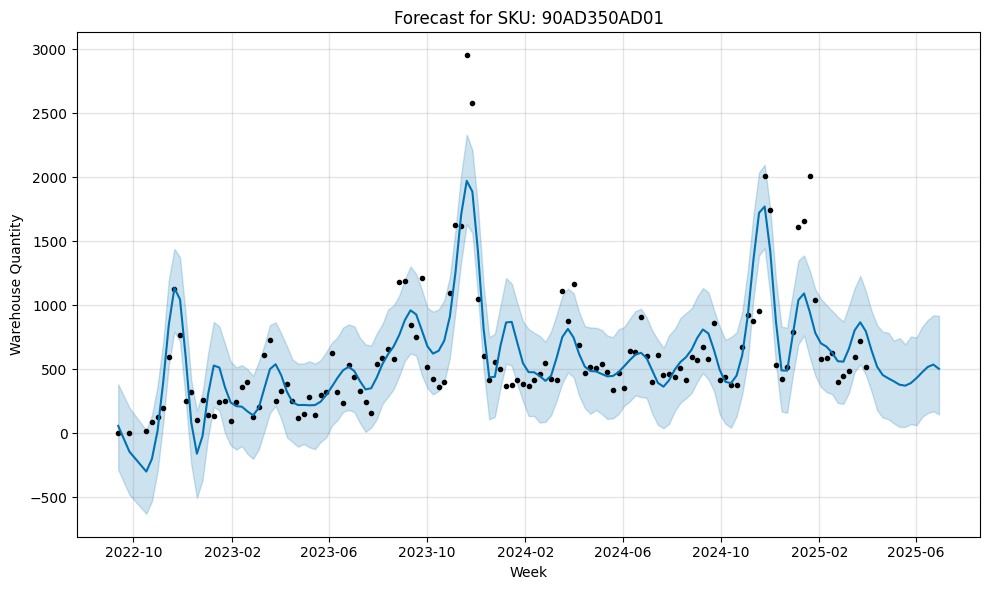

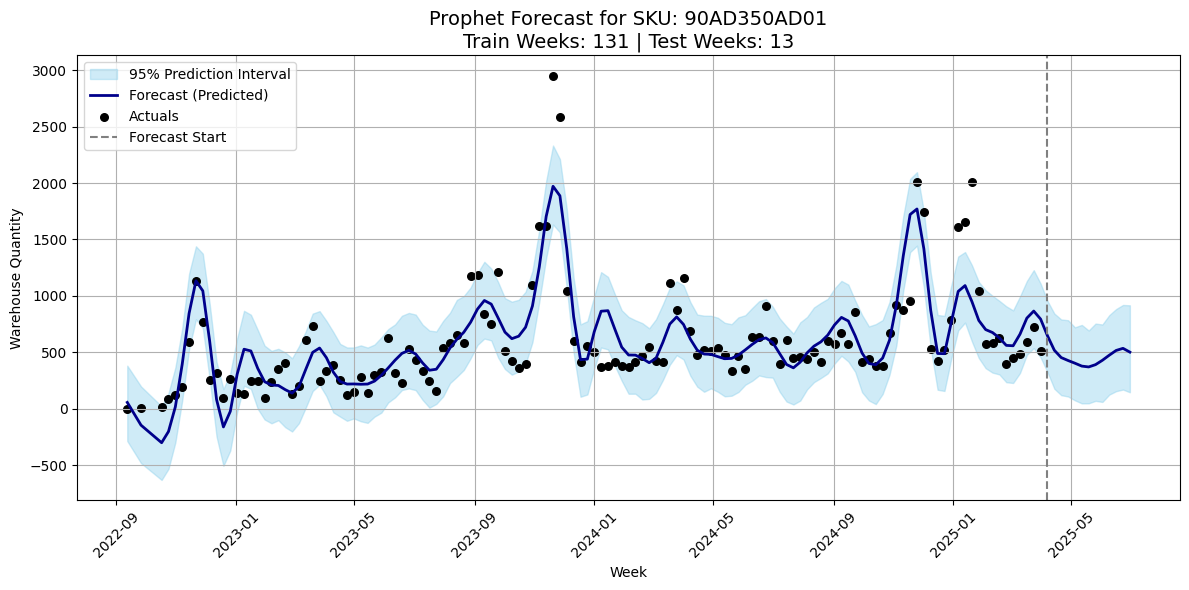


Forecast vs Actuals (Test Period):
            ds  WareHouseQuantity        yhat
131 2025-04-07              738.0  647.371748
132 2025-04-14              432.0  519.038459
133 2025-04-21              541.0  454.013202
134 2025-04-28              509.0  428.065072
135 2025-05-05              506.0  404.106412
136 2025-05-12              486.0  378.446411
137 2025-05-19              318.0  371.013167
138 2025-05-26              414.0  391.331609
139 2025-06-02              375.0  430.023210
140 2025-06-09              474.0  475.105984
141 2025-06-16              475.0  517.095288
142 2025-06-23              390.0  535.840302
143 2025-06-30              388.0  502.380065

Accuracy Metrics:
MAE  (Mean Absolute Error):        76.09
MSE  (Mean Squared Error):         7256.43
RMSE (Root Mean Squared Error):    85.18
MAPE (Mean Absolute % Error):      16.88%
R²   (R-squared Score):            0.27


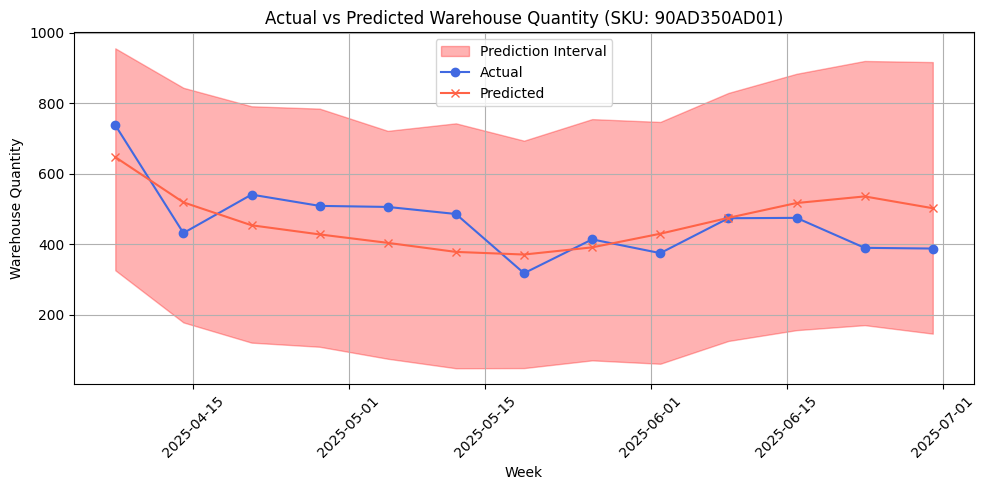


Final Forecast Results with Rounded Predictions:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference
131,2025-04-07,2025-04-13,738.0,647,-90.628252,-12.28%
132,2025-04-14,2025-04-20,432.0,519,87.038459,20.15%
133,2025-04-21,2025-04-27,541.0,454,-86.986798,-16.08%
134,2025-04-28,2025-05-04,509.0,428,-80.934928,-15.9%
135,2025-05-05,2025-05-11,506.0,404,-101.893588,-20.14%
136,2025-05-12,2025-05-18,486.0,378,-107.553589,-22.13%
137,2025-05-19,2025-05-25,318.0,371,53.013167,16.67%
138,2025-05-26,2025-06-01,414.0,391,-22.668391,-5.48%
139,2025-06-02,2025-06-08,375.0,430,55.023210,14.67%
140,2025-06-09,2025-06-15,474.0,475,1.105984,0.23%


In [62]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    yearly_seasonality=True,
    # weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=1.0,
    seasonality_prior_scale=10.0,
    holidays_prior_scale=0.0010529503714950096
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)


# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Enhanced Visualization)
historical = prophet_df.copy()
historical['label'] = 'Actuals'
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

plt.figure(figsize=(12, 6))
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 6: Merge actual test data
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actuals
print("\nForecast vs Actuals (Test Period):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuantity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Final Results DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Round predicted values for display only
test_forecast['Rounded_Predicted'] = test_forecast['predicted'].round().astype(int)
test_forecast['Percent_Difference'] = test_forecast['Percent_Difference'].round(2).astype(str) + '%'

# Final presentation DataFrame
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
}, inplace=True)

# Optional: Save to CSV
# final_result.to_csv("actual_vs_predicted_forecast_results.csv", index=False)

# Show final result
print("\nFinal Forecast Results with Rounded Predictions:")
final_result


### Final Results (With r2_score=0.31)

11:14:41 - cmdstanpy - INFO - Chain [1] start processing



Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


11:14:41 - cmdstanpy - INFO - Chain [1] done processing


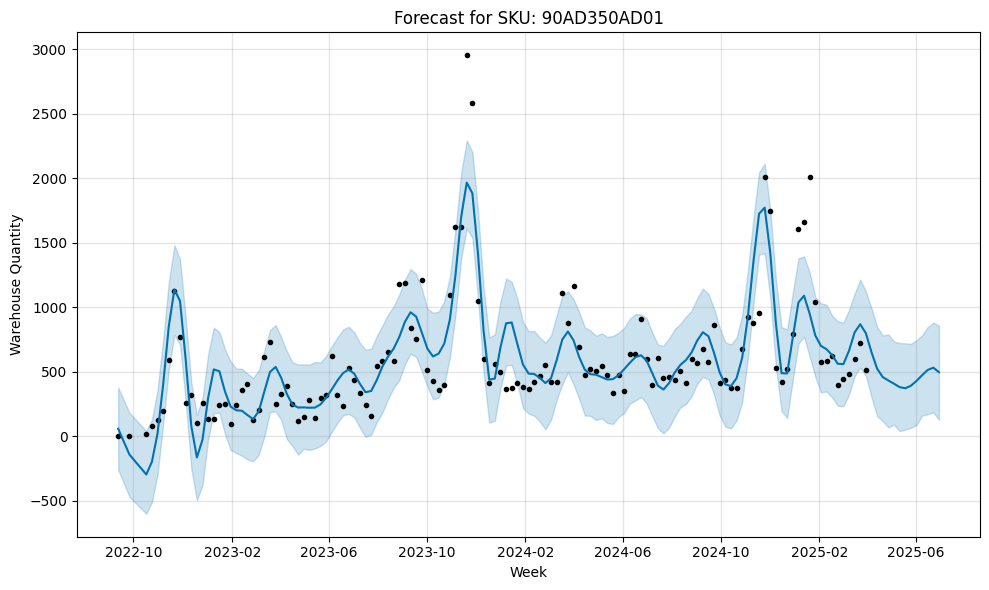

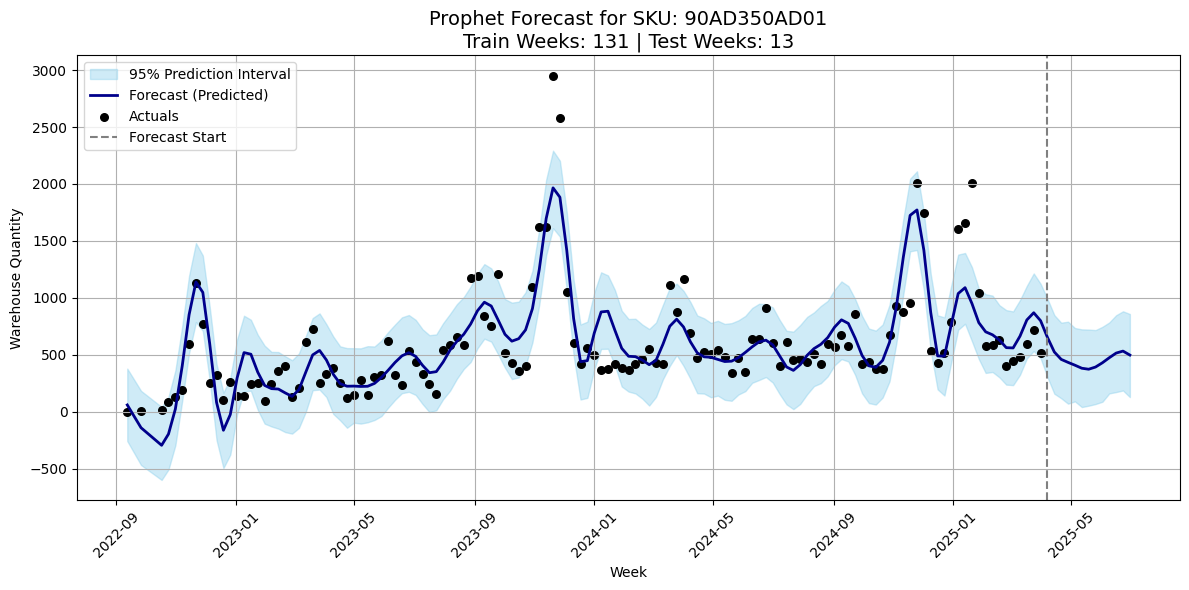


Forecast vs Actuals (Test Period):
            ds  WareHouseQuantity        yhat
131 2025-04-07              738.0  651.795211
132 2025-04-14              432.0  524.103811
133 2025-04-21              541.0  459.156536
134 2025-04-28              509.0  432.769425
135 2025-05-05              506.0  408.027363
136 2025-05-12              486.0  381.333974
137 2025-05-19              318.0  372.684672
138 2025-05-26              414.0  391.943756
139 2025-06-02              375.0  429.402024
140 2025-06-09              474.0  473.560427
141 2025-06-16              475.0  514.514797
142 2025-06-23              390.0  531.969645
143 2025-06-30              388.0  497.193854

Accuracy Metrics:
MAE  (Mean Absolute Error):        73.94
MSE  (Mean Squared Error):         6850.32
RMSE (Root Mean Squared Error):    82.77
MAPE (Mean Absolute % Error):      16.46%
R²   (R-squared Score):            0.31


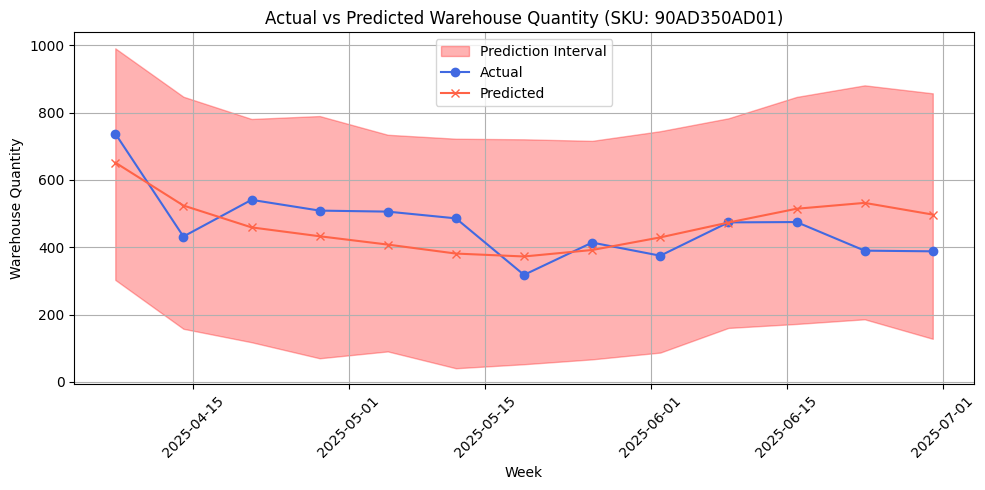


Final Forecast Results with Rounded Predictions:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference
131,2025-04-07,2025-04-13,738.0,652,-86.204789,-11.68%
132,2025-04-14,2025-04-20,432.0,524,92.103811,21.32%
133,2025-04-21,2025-04-27,541.0,459,-81.843464,-15.13%
134,2025-04-28,2025-05-04,509.0,433,-76.230575,-14.98%
135,2025-05-05,2025-05-11,506.0,408,-97.972637,-19.36%
136,2025-05-12,2025-05-18,486.0,381,-104.666026,-21.54%
137,2025-05-19,2025-05-25,318.0,373,54.684672,17.2%
138,2025-05-26,2025-06-01,414.0,392,-22.056244,-5.33%
139,2025-06-02,2025-06-08,375.0,429,54.402024,14.51%
140,2025-06-09,2025-06-15,474.0,474,-0.439573,-0.09%


In [68]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=1.0,
    seasonality_prior_scale=5.0,
    holidays_prior_scale=0.00801378512898308
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)


# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Enhanced Visualization)
historical = prophet_df.copy()
historical['label'] = 'Actuals'
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

plt.figure(figsize=(12, 6))
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 6: Merge actual test data
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actuals
print("\nForecast vs Actuals (Test Period):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuantity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Final Results DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Round predicted values for display only
test_forecast['Rounded_Predicted'] = test_forecast['predicted'].round().astype(int)
test_forecast['Percent_Difference'] = test_forecast['Percent_Difference'].round(2).astype(str) + '%'

# Final presentation DataFrame
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
}, inplace=True)

# Optional: Save to CSV
# final_result.to_csv("actual_vs_predicted_forecast_results.csv", index=False)

# Show final result
print("\nFinal Forecast Results with Rounded Predictions:")
final_result


In [76]:
train_data

,Week,WareHouseQuantity,Week_End
Week_Start,,,
2022-09-12,2022-09-12,1,2022-09-18
2022-09-26,2022-09-26,5,2022-10-02
2022-10-17,2022-10-17,17,2022-10-23
2022-10-24,2022-10-24,84,2022-10-30
2022-10-31,2022-10-31,125,2022-11-06
...,...,...,...
2025-03-03,2025-03-03,447,2025-03-09
2025-03-10,2025-03-10,482,2025-03-16
2025-03-17,2025-03-17,596,2025-03-23


### Results With Plus Minus 10%

c:\forecasting\datasets\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


12:05:19 - cmdstanpy - INFO - Chain [1] start processing
12:05:20 - cmdstanpy - INFO - Chain [1] done processing


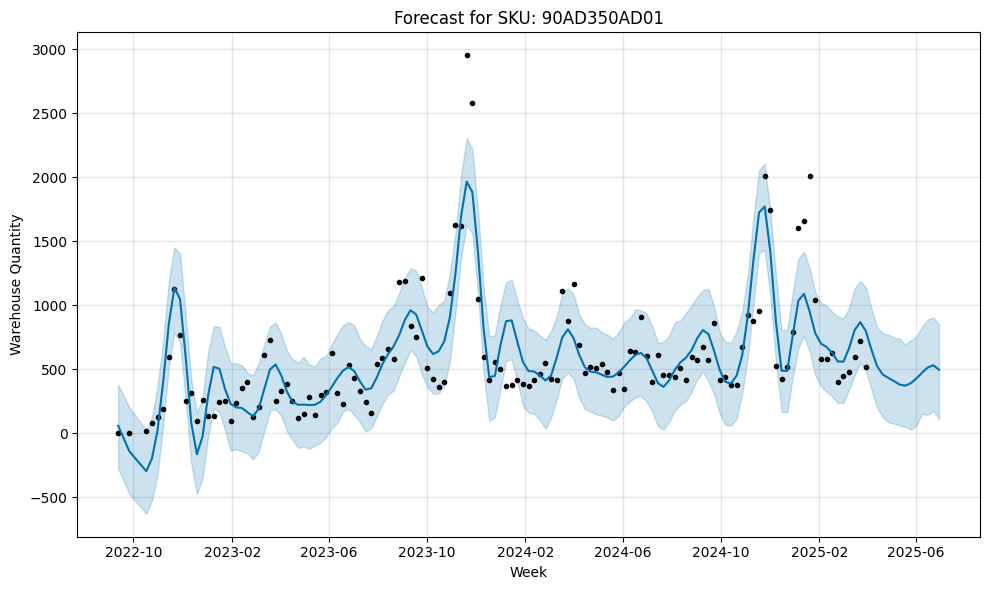

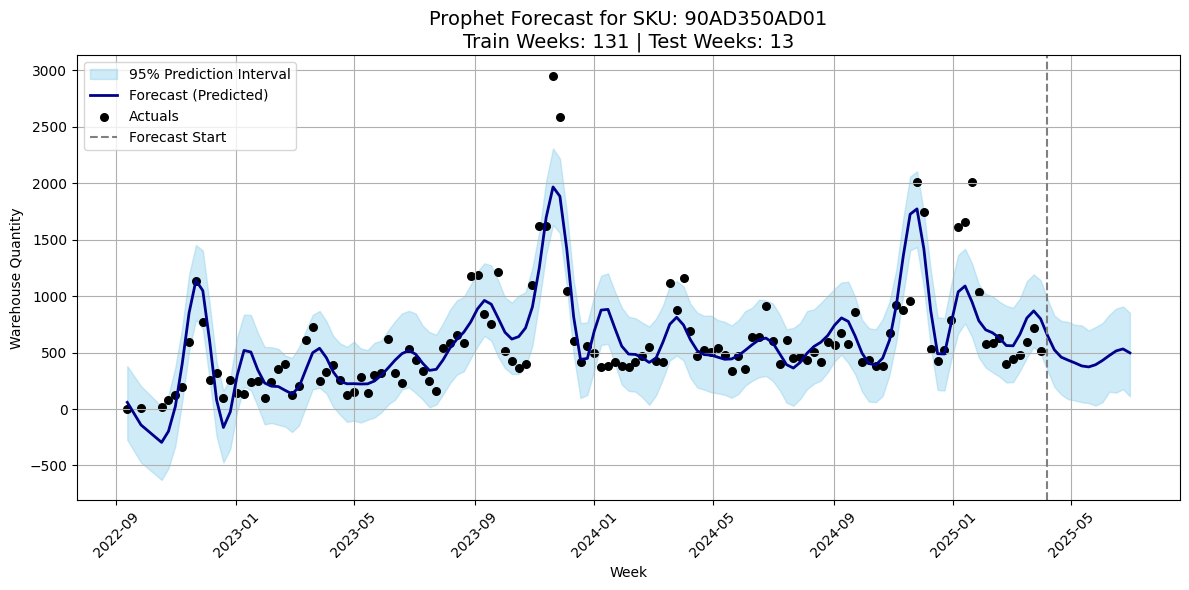


Forecast vs Actuals (Test Period):
            ds  WareHouseQuantity        yhat
131 2025-04-07              738.0  651.795211
132 2025-04-14              432.0  524.103811
133 2025-04-21              541.0  459.156536
134 2025-04-28              509.0  432.769425
135 2025-05-05              506.0  408.027363
136 2025-05-12              486.0  381.333974
137 2025-05-19              318.0  372.684672
138 2025-05-26              414.0  391.943756
139 2025-06-02              375.0  429.402024
140 2025-06-09              474.0  473.560427
141 2025-06-16              475.0  514.514797
142 2025-06-23              390.0  531.969645
143 2025-06-30              388.0  497.193854

Accuracy Metrics:
MAE  (Mean Absolute Error):        73.94
MSE  (Mean Squared Error):         6850.32
RMSE (Root Mean Squared Error):    82.77
MAPE (Mean Absolute % Error):      16.46%
R²   (R-squared Score):            0.31


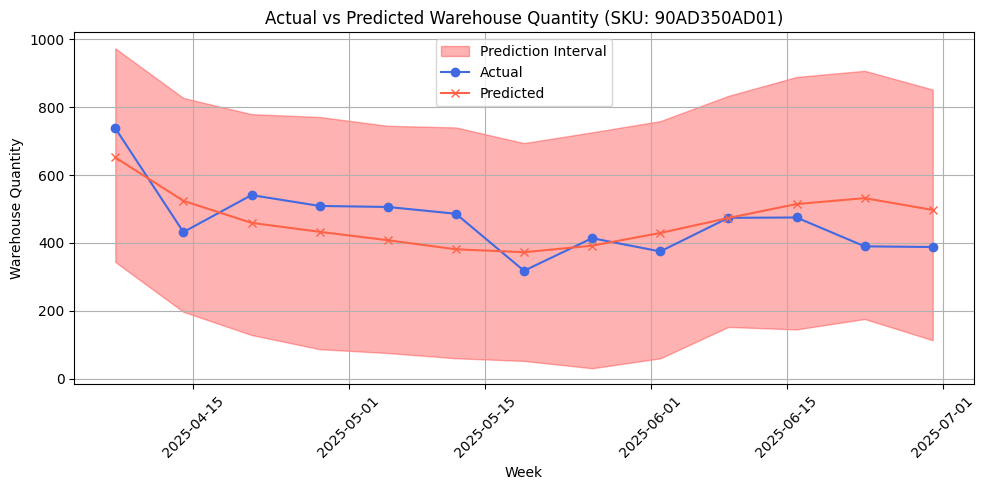


Accuracy within ±10% of predicted values: 23.08%

Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
131,2025-04-07,2025-04-13,738.0,652,-86.204789,-11.68%,664,812,Out of Range
132,2025-04-14,2025-04-20,432.0,524,92.103811,21.32%,389,475,Out of Range
133,2025-04-21,2025-04-27,541.0,459,-81.843464,-15.13%,487,595,Out of Range
134,2025-04-28,2025-05-04,509.0,433,-76.230575,-14.98%,458,560,Out of Range
135,2025-05-05,2025-05-11,506.0,408,-97.972637,-19.36%,455,557,Out of Range
136,2025-05-12,2025-05-18,486.0,381,-104.666026,-21.54%,437,535,Out of Range
137,2025-05-19,2025-05-25,318.0,373,54.684672,17.2%,286,350,Out of Range
138,2025-05-26,2025-06-01,414.0,392,-22.056244,-5.33%,373,455,Acceptable
139,2025-06-02,2025-06-08,375.0,429,54.402024,14.51%,338,413,Out of Range
140,2025-06-09,2025-06-15,474.0,474,-0.439573,-0.09%,427,521,Acceptable


In [31]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=1.0,
    seasonality_prior_scale=5.0,
    holidays_prior_scale=0.00801378512898308
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)

# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Enhanced Visualization)
historical = prophet_df.copy()
historical['label'] = 'Actuals'
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

plt.figure(figsize=(12, 6))
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 6: Merge actual test data
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actuals
print("\nForecast vs Actuals (Test Period):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuantity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Final Results DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Round predicted values for display only
test_forecast['Rounded_Predicted'] = test_forecast['predicted'].round().astype(int)
test_forecast['Percent_Difference'] = test_forecast['Percent_Difference'].round(2).astype(str) + '%'

# Final presentation DataFrame
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
}, inplace=True)

# STEP 10: ±10% Accuracy Evaluation
final_result['Minus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 0.90).round().astype(int)
final_result['Plus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 1.10).round().astype(int)

final_result['Within_10_Percent'] = (
    (final_result['Predicted_WareHouseQuantity'] >= final_result['Minus_10_Percent']) &
    (final_result['Predicted_WareHouseQuantity'] <= final_result['Plus_10_Percent'])
)

# Convert to readable format
final_result['Within_10_Percent'] = final_result['Within_10_Percent'].map({True: 'Acceptable', False: 'Out of Range'})

# Accuracy within ±10% band
accuracy_within_10_percent = (final_result['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")

# Display final results
print("\nFinal Forecast Results:")
# print(final_result)

# Optional: Save to CSV
# final_result.to_csv("forecast_results_with_10_percent_band.csv", index=False)
final_result


### LSTM Model

In [32]:
# pip install tensorflow

In [52]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ----- STEP 1: Prepare Data -----
# Assume train_data and test_data are already defined with columns ['Week_Start', 'Week_End', 'WareHouseQuantity']
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target column
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----- STEP 2: Create Sequences -----
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 4
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Align time indexes
time_data = df.iloc[sequence_length:].reset_index(drop=True)
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----- STEP 3: Build LSTM Model -----
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], 1), return_sequences=False))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

# ----- STEP 4: Train -----
model.fit(X_train, y_train, epochs=200, batch_size=8, verbose=1)

# ----- STEP 5: Predict -----
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test)

# ----- STEP 6: Evaluation -----
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----- STEP 7: Result DataFrame -----
# Extract Start and End week for each prediction
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})



result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})
# Accuracy within ±10% band
accuracy_within_10_percent = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")
print(result_df.head())

# ----- Optional: Save to CSV -----
# result_df.to_csv('lstm_forecast_results.csv', index=False)
result_df

Epoch 1/200


c:\forecasting\datasets\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0324
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0212 
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0195 
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0187 
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0180 
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0173 
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0167 
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0160 
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0153 
Epoch 10/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0147 
Epoch 11/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0141 
Epoch 12/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0136 
Epoch 13/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0133 
Epoch 14/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0129 
Epoch 15/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0127 
Ep

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,526,-212.0,-28.73,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,749,317.0,73.38,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,448,-93.0,-17.19,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,565,56.0,11.00,458.1,559.9,Out of Range
4,2025-05-05,2025-05-11,506.0,529,23.0,4.55,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,504,18.0,3.70,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,526,208.0,65.41,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,390,-24.0,-5.80,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,470,95.0,25.33,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,424,-50.0,-10.55,426.6,521.4,Out of Range


In [57]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ----- STEP 1: Prepare Data -----
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target column
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----- STEP 2: Create Sequences -----
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 4
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Align time indexes
time_data = df.iloc[sequence_length:].reset_index(drop=True)
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----- STEP 3: Build LSTM Model -----
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], 1)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

# ----- STEP 4: Train -----
model.fit(X_train, y_train, epochs=200, batch_size=8, verbose=1)

# ----- STEP 5: Predict -----
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----- STEP 6: Evaluation -----
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----- STEP 7: Result DataFrame -----
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

# ----- Accuracy within ±10% Band -----
accuracy_within_10_percent = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")

# ----- Output -----
# print(result_df.head())
# result_df.to_csv('lstm_forecast_results.csv', index=False)
result_df


Epoch 1/200


c:\forecasting\datasets\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0547 - mae: 0.1732
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0268 - mae: 0.1076 
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0226 - mae: 0.1046 
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0215 - mae: 0.1002 
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0211 - mae: 0.0999 
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0206 - mae: 0.0984 
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0202 - mae: 0.0975 
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0197 - mae: 0.0965 
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0192 - mae: 0.0950 
Epoch 10/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0187 - mae: 0.0944 
Epoch 11/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0182 - mae: 0.0926 
Epoch 12/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0175 - mae: 0.0908 
Epoch 13/200
16/16 ━━━━━━━━━━━━━━━━━━━

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,594,-144.0,-19.51,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,819,387.0,89.58,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,451,-90.0,-16.64,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,634,125.0,24.56,458.1,559.9,Out of Range
4,2025-05-05,2025-05-11,506.0,538,32.0,6.32,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,590,104.0,21.40,437.4,534.6,Out of Range
6,2025-05-19,2025-05-25,318.0,563,245.0,77.04,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,410,-4.0,-0.97,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,501,126.0,33.60,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,437,-37.0,-7.81,426.6,521.4,Acceptable


#### Actual vs Predicted

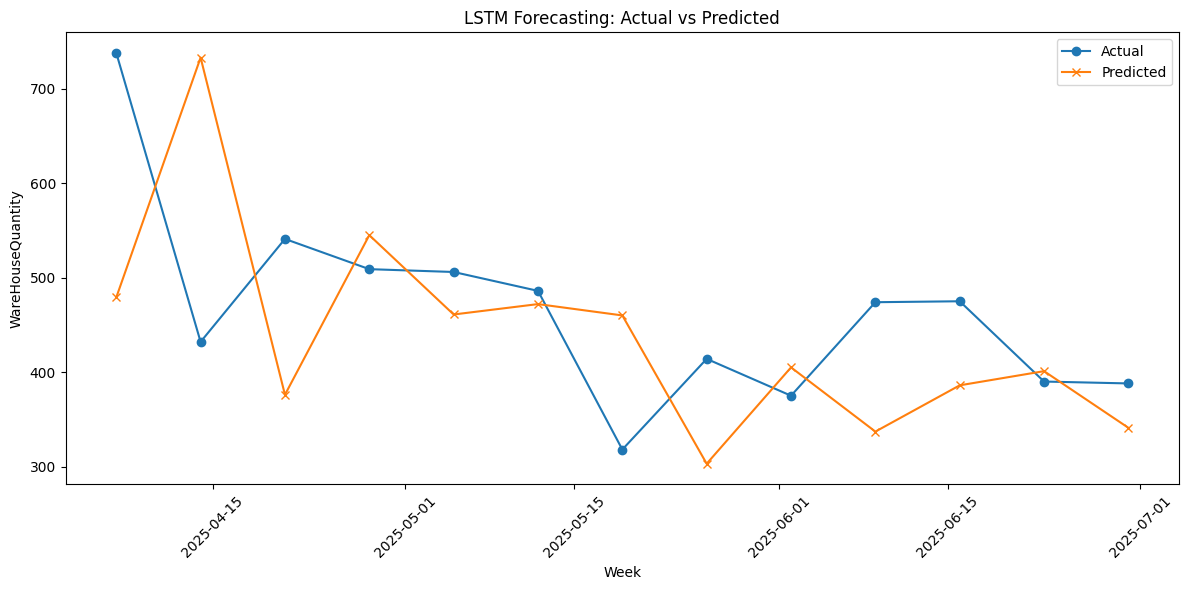

In [54]:
plt.figure(figsize=(12, 6))
plt.plot(result_df['Start_Week'], result_df['Actual_WareHouseQuantity'], label='Actual', marker='o')
plt.plot(result_df['Start_Week'], result_df['Predicted_WareHouseQuantity'], label='Predicted', marker='x')
plt.xticks(rotation=45)
plt.title('LSTM Forecasting: Actual vs Predicted')
plt.xlabel('Week')
plt.ylabel('WareHouseQuantity')
plt.legend()
plt.tight_layout()
plt.show()


In [70]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

# ----- STEP 1: Prepare Data -----
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target column
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----- STEP 2: Create Sequences -----
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 8
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Align time indexes
time_data = df.iloc[sequence_length:].reset_index(drop=True)
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----- STEP 3: Build Deeper LSTM Model -----
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], 1)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # Use sigmoid for scaling output
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae'])

# ----- STEP 4: Train -----
model.fit(X_train, y_train, epochs=300, batch_size=8, verbose=1)

# ----- STEP 5: Predict -----
y_pred_scaled = model.predict(X_test)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----- STEP 6: Evaluation -----
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----- STEP 7: Result DataFrame -----
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

# ----- Accuracy within ±10% Band -----
accuracy_within_10_percent = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")

# ----- Output -----
# result_df.to_csv('lstm_forecast_results.csv', index=False)
result_df


c:\forecasting\datasets\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1006 - mae: 0.3012
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0418 - mae: 0.1678
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0401 - mae: 0.1380
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0277 - mae: 0.1102
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0289 - mae: 0.1103
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0271 - mae: 0.1074
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0271 - mae: 0.1073
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0266 - mae: 0.1067
Epoch 9/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0264 - mae: 0.1064
Epoch 10/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0262 - mae: 0.1062
Epoch 11/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0260 - mae: 0.1057
Epoch 12/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0258 - mae: 0.1056
Epoch 13/300
16/16 ━━━━━━━━

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,586,-152.0,-20.60,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,597,165.0,38.19,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,484,-57.0,-10.54,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,443,-66.0,-12.97,458.1,559.9,Out of Range
4,2025-05-05,2025-05-11,506.0,444,-62.0,-12.25,455.4,556.6,Out of Range
5,2025-05-12,2025-05-18,486.0,504,18.0,3.70,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,512,194.0,61.01,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,430,16.0,3.86,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,459,84.0,22.40,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,436,-38.0,-8.02,426.6,521.4,Acceptable


In [81]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import matplotlib.pyplot as plt

# ----------------------- STEP 0: Set Random Seed -----------------------
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ----------------------- STEP 1: Prepare Data -----------------------
# Combine train and test
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----------------------- STEP 2: Create Sequences -----------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 4
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

# Time alignment
X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----------------------- STEP 3: Build Model -----------------------
model = Sequential([
    LSTM(128, input_shape=(sequence_length, 1)),
    Dense(64, activation='mish'),
    Dense(32, activation='mish'),
    Dense(16, activation='mish'),
    Dense(1, activation='sigmoid')  # Because scaled
])

model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# ----------------------- STEP 4: Train Model -----------------------
model.fit(X_train, y_train, epochs=300, batch_size=8, verbose=1)

# ----------------------- STEP 5: Predict -----------------------
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----------------------- STEP 6: Evaluation -----------------------
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----------------------- STEP 7: Result DataFrame -----------------------
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# Optionally save
# result_df.to_csv("lstm_forecast_results.csv", index=False)

# Return result
result_df


Epoch 1/300


c:\forecasting\datasets\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0863 - mae: 0.2745
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0351 - mae: 0.1320
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0288 - mae: 0.1089
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0271 - mae: 0.1145
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0261 - mae: 0.1069
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0255 - mae: 0.1060
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0250 - mae: 0.1065
Epoch 8/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0244 - mae: 0.1057 
Epoch 9/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0236 - mae: 0.1055
Epoch 10/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0232 - mae: 0.1044
Epoch 11/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0227 - mae: 0.1038
Epoch 12/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0220 - mae: 0.1029
Epoch 13/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,500,-238.0,-32.25,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,751,319.0,73.84,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,472,-69.0,-12.75,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,556,47.0,9.23,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,571,65.0,12.85,455.4,556.6,Out of Range
5,2025-05-12,2025-05-18,486.0,496,10.0,2.06,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,517,199.0,62.58,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,381,-33.0,-7.97,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,462,87.0,23.20,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,425,-49.0,-10.34,426.6,521.4,Out of Range


In [79]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Normalization
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt

# ----------------------- STEP 0: Set Random Seed -----------------------
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ----------------------- STEP 1: Prepare Data -----------------------
# Combine train and test
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# ----------------------- STEP 2: Create Sequences -----------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 4
data = df[['WareHouseQuantity']].values.astype(np.float32)
X_all, y_all = create_sequences(data, sequence_length)

X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# ----------------------- STEP 3: Build Model -----------------------
normalizer = Normalization()
normalizer.adapt(X_train)

model = Sequential([
    normalizer,
    LSTM(128, return_sequences=False),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

optimizer = AdamW(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# ----------------------- STEP 4: Training with LR Scheduler -----------------------
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=8,
    validation_split=0.1,
    callbacks=[lr_scheduler],
    verbose=1
)

# ----------------------- STEP 5: Predict -----------------------
y_pred = model.predict(X_test, verbose=0)

# ----------------------- STEP 6: Evaluation -----------------------
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# ----------------------- STEP 7: Result DataFrame -----------------------
start_weeks = test_data['Week_Start'].iloc[:len(y_test)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_test)].reset_index(drop=True)

actuals = pd.Series(y_test.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# Return result
result_df


Epoch 1/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 551028.1250 - mae: 587.9739 - val_loss: 1017638.0000 - val_mae: 865.1827 - learning_rate: 0.0010
Epoch 2/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 549239.0000 - mae: 586.8042 - val_loss: 1009957.1250 - val_mae: 860.4850 - learning_rate: 0.0010
Epoch 3/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 540861.3750 - mae: 581.2642 - val_loss: 971543.5625 - val_mae: 835.5516 - learning_rate: 0.0010
Epoch 4/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 495148.7500 - mae: 546.4332 - val_loss: 798627.2500 - val_mae: 719.4577 - learning_rate: 0.0010
Epoch 5/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 321414.9062 - mae: 373.0814 - val_loss: 416954.3750 - val_mae: 398.4868 - learning_rate: 0.0010
Epoch 6/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 202447.1406 - mae: 307.1956 - val_loss: 301384.1250 - val_mae: 384.5913 - learning_rate: 0.0010
Epoch 7/300
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 20

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,573,-165.0,-22.36,664.200012,811.799988,Out of Range
1,2025-04-14,2025-04-20,432.0,665,233.0,53.94,388.799988,475.200012,Out of Range
2,2025-04-21,2025-04-27,541.0,333,-208.0,-38.45,486.899994,595.099976,Out of Range
3,2025-04-28,2025-05-04,509.0,621,112.0,22.00,458.100006,559.900024,Out of Range
4,2025-05-05,2025-05-11,506.0,415,-91.0,-17.98,455.399994,556.599976,Out of Range
5,2025-05-12,2025-05-18,486.0,640,154.0,31.69,437.399994,534.599976,Out of Range
6,2025-05-19,2025-05-25,318.0,582,264.0,83.02,286.200012,349.799988,Out of Range
7,2025-05-26,2025-06-01,414.0,486,72.0,17.39,372.600006,455.399994,Out of Range
8,2025-06-02,2025-06-08,375.0,624,249.0,66.40,337.500000,412.500000,Out of Range
9,2025-06-09,2025-06-15,474.0,560,86.0,18.14,426.600006,521.400024,Out of Range


In [82]:
pip install keras-tuner



   ---------------------------------------- 0/2 [kt-legacy]
   ---------------------------------------- 0/2 [kt-legacy]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   -------------------- ------------------- 1/2 [keras-tuner]
   ---------------------------------------- 2/2 [keras-tuner]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [83]:
import keras_tuner as kt

def build_model(hp):
    model = Sequential()
    model.add(LSTM(
        hp.Int('lstm_units', min_value=64, max_value=256, step=64),
        input_shape=(sequence_length, 1)))
    
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(Dense(
            units=hp.Int(f'dense_units_{i}', min_value=16, max_value=128, step=16),
            activation=hp.Choice('activation', ['relu', 'mish', 'swish'])))
    
    model.add(Dense(1))  # Linear activation

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Float('learning_rate', 1e-4, 1e-2, sampling='log')),
        loss='mse',
        metrics=['mae'])
    
    return model

tuner = kt.RandomSearch(
    build_model,
    objective='val_mae',
    max_trials=10,
    executions_per_trial=1,
    directory='lstm_tuning',
    project_name='forecast_tune')

tuner.search(X_train, y_train, epochs=50, validation_split=0.2, verbose=2)

# Get best model
best_model = tuner.get_best_models(num_models=1)[0]


Trial 10 Complete [00h 00m 07s]
val_mae: 0.08482074737548828

Best val_mae So Far: 0.08482074737548828
Total elapsed time: 00h 01m 17s


c:\forecasting\datasets\.venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 20 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [84]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print("Best Hyperparameters Found:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")


Best Hyperparameters Found:
lstm_units: 192
num_layers: 2
dense_units_0: 64
activation: mish
learning_rate: 0.009339162607282521
dense_units_1: 32
dense_units_2: 128


In [104]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ----------------------- STEP 0: Set Random Seed -----------------------
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ----------------------- STEP 1: Prepare Data -----------------------
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----------------------- STEP 2: Create Sequences -----------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 18
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----------------------- STEP 3: Build Model -----------------------
model = Sequential()
model.add(LSTM(192, input_shape=(sequence_length, 1)))
model.add(Dense(64, activation='mish'))
model.add(Dense(32, activation='mish'))
model.add(Dense(1))  # Linear activation for regression

# ----------------------- STEP 4: Compile -----------------------
optimizer = Adam(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# ----------------------- STEP 5: Callbacks -----------------------
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5, min_lr=1e-6, verbose=1)

# ----------------------- STEP 6: Train Model -----------------------
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ----------------------- STEP 7: Predict -----------------------
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----------------------- STEP 8: Evaluation -----------------------
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----------------------- STEP 9: Result DataFrame -----------------------
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# Optionally save model and results
# model.save("best_lstm_model.h5")
# result_df.to_csv("best_model_results.csv", index=False)

# Return result
result_df


Epoch 1/200


c:\forecasting\datasets\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step - loss: 0.1285 - mae: 0.3023 - val_loss: 0.0832 - val_mae: 0.2412 - learning_rate: 0.0100
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 0.0558 - mae: 0.1840 - val_loss: 0.0633 - val_mae: 0.1961 - learning_rate: 0.0100
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0431 - mae: 0.1337 - val_loss: 0.0298 - val_mae: 0.1116 - learning_rate: 0.0100
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0289 - mae: 0.1224 - val_loss: 0.0347 - val_mae: 0.1094 - learning_rate: 0.0100
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0346 - mae: 0.1317 - val_loss: 0.0323 - val_mae: 0.1178 - learning_rate: 0.0100
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 0.0241 - mae: 0.0940 - val_loss: 0.0344 - val_mae: 0.1105 - learning_rate: 0.0100
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0257 - mae: 0.0957 - val_loss: 0.0277 - val_mae: 0.0991 - learning_rate: 0.0100
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,573,-165.0,-22.36,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,633,201.0,46.53,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,449,-92.0,-17.01,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,490,-19.0,-3.73,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,502,-4.0,-0.79,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,520,34.0,7.00,437.4,534.6,Acceptable
6,2025-05-19,2025-05-25,318.0,523,205.0,64.47,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,425,11.0,2.66,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,466,91.0,24.27,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,457,-17.0,-3.59,426.6,521.4,Acceptable


In [107]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

# ----------------------- STEP 0: Set Random Seed -----------------------
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# ----------------------- STEP 1: Prepare Data -----------------------
df = pd.concat([train_data, test_data]).reset_index(drop=True)

# Normalize target
scaler = MinMaxScaler()
scaled_quantity = scaler.fit_transform(df[['WareHouseQuantity']])

# ----------------------- STEP 2: Create Sequences -----------------------
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(len(data) - sequence_length):
        X.append(data[i:i+sequence_length])
        y.append(data[i+sequence_length])
    return np.array(X), np.array(y)

sequence_length = 18
X_all, y_all = create_sequences(scaled_quantity, sequence_length)

X_train = X_all[:len(train_data) - sequence_length]
y_train = y_all[:len(train_data) - sequence_length]
X_test = X_all[len(train_data) - sequence_length:]
y_test = y_all[len(train_data) - sequence_length:]

# Reshape for LSTM
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# ----------------------- STEP 3: Build Model -----------------------
model = Sequential()
model.add(LSTM(192, input_shape=(sequence_length, 1)))
model.add(Dense(100, activation='mish'))
model.add(Dense(100, activation='mish'))
model.add(Dense(100, activation='mish'))
model.add(Dense(1))  # Linear activation for regression

# ----------------------- STEP 4: Compile -----------------------
optimizer = AdamW(learning_rate=0.01)
model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

# ----------------------- STEP 5: Callbacks -----------------------
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', patience=10, factor=0.5, min_lr=1e-6, verbose=1)

# ----------------------- STEP 6: Train Model -----------------------
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=128,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ----------------------- STEP 7: Predict -----------------------
y_pred_scaled = model.predict(X_test, verbose=0)
y_pred = scaler.inverse_transform(y_pred_scaled)
y_true = scaler.inverse_transform(y_test.reshape(-1, 1))

# ----------------------- STEP 8: Evaluation -----------------------
print("MAE:", mean_absolute_error(y_true, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
print("R2 Score:", r2_score(y_true, y_pred))

# ----------------------- STEP 9: Result DataFrame -----------------------
start_weeks = test_data['Week_Start'].iloc[:len(y_true)].reset_index(drop=True)
end_weeks = test_data['Week_End'].iloc[:len(y_true)].reset_index(drop=True)

actuals = pd.Series(y_true.flatten()).reset_index(drop=True)
predicted = pd.Series(np.round(y_pred.flatten()).astype(int)).reset_index(drop=True)
difference = predicted - actuals
percent_diff = ((difference / actuals) * 100).round(2)
minus_10 = (actuals * 0.9).round(2)
plus_10 = (actuals * 1.1).round(2)
within_10 = (predicted >= minus_10) & (predicted <= plus_10)
status = within_10.map({True: "Acceptable", False: "Out of Range"})

result_df = pd.DataFrame({
    'Start_Week': start_weeks,
    'End_Week': end_weeks,
    'Actual_WareHouseQuantity': actuals,
    'Predicted_WareHouseQuantity': predicted,
    'Difference_Between_Predicted_And_Actual': difference,
    'Percent_Difference': percent_diff,
    'Minus_10_Percent': minus_10,
    'Plus_10_Percent': plus_10,
    'Within_10_Percent': status
})

accuracy_within_10 = (result_df['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10:.2f}%")

# Optionally save model and results
# model.save("best_lstm_model.h5")
# result_df.to_csv("best_model_results.csv", index=False)

# Return result
result_df


Epoch 1/200


c:\forecasting\datasets\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0721 - mae: 0.2166 - val_loss: 0.0418 - val_mae: 0.1969 - learning_rate: 0.0100
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - loss: 0.0305 - mae: 0.1501 - val_loss: 0.0988 - val_mae: 0.2673 - learning_rate: 0.0100
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0634 - mae: 0.1913 - val_loss: 0.0372 - val_mae: 0.1145 - learning_rate: 0.0100
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - loss: 0.0278 - mae: 0.0991 - val_loss: 0.0316 - val_mae: 0.1328 - learning_rate: 0.0100
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - loss: 0.0268 - mae: 0.1249 - val_loss: 0.0294 - val_mae: 0.1068 - learning_rate: 0.0100
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 0.0242 - mae: 0.1069 - val_loss: 0.0560 - val_mae: 0.1775 - learning_rate: 0.0100
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0399 - mae: 0.1300 - val_loss: 0.0260 - val_mae: 0.1348 - learning_rate: 0.0100
Epoch 8/200
1/1 ━━━━━━━━━━━━━━

,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738.0,534,-204.0,-27.64,664.2,811.8,Out of Range
1,2025-04-14,2025-04-20,432.0,634,202.0,46.76,388.8,475.2,Out of Range
2,2025-04-21,2025-04-27,541.0,483,-58.0,-10.72,486.9,595.1,Out of Range
3,2025-04-28,2025-05-04,509.0,506,-3.0,-0.59,458.1,559.9,Acceptable
4,2025-05-05,2025-05-11,506.0,535,29.0,5.73,455.4,556.6,Acceptable
5,2025-05-12,2025-05-18,486.0,542,56.0,11.52,437.4,534.6,Out of Range
6,2025-05-19,2025-05-25,318.0,527,209.0,65.72,286.2,349.8,Out of Range
7,2025-05-26,2025-06-01,414.0,405,-9.0,-2.17,372.6,455.4,Acceptable
8,2025-06-02,2025-06-08,375.0,446,71.0,18.93,337.5,412.5,Out of Range
9,2025-06-09,2025-06-15,474.0,455,-19.0,-4.01,426.6,521.4,Acceptable


### ARIMA Implementation


Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


c:\forecasting\datasets\.venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


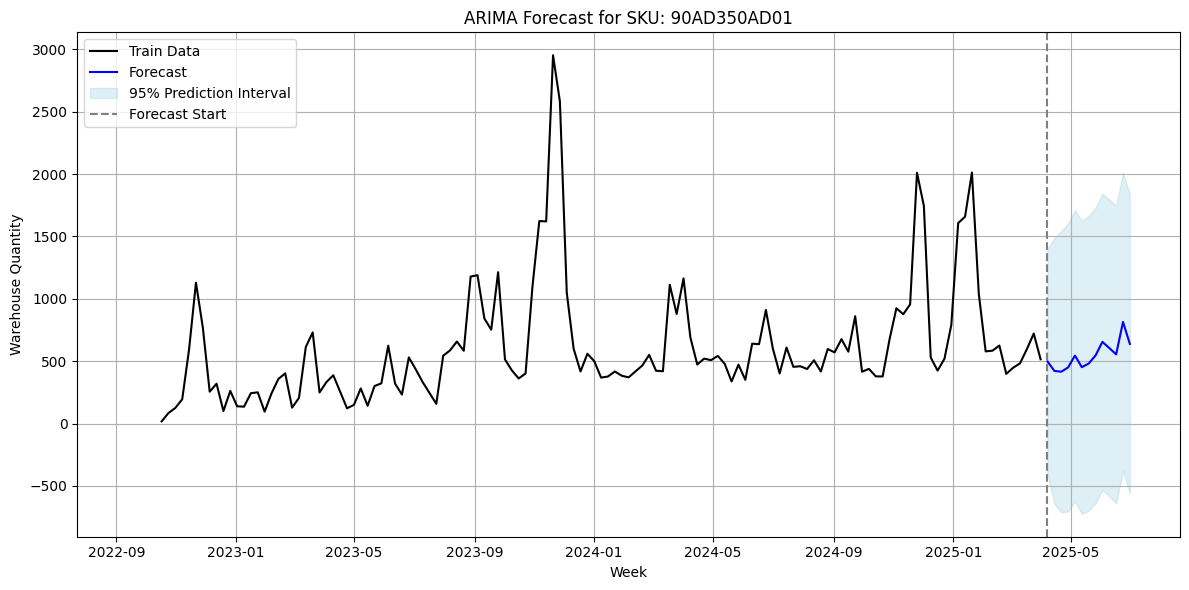


Forecast vs Actuals (Test Period):
             ds  WareHouseQuantity        yhat
1950 2025-04-07                738  497.710047
1959 2025-04-14                432  421.673345
1968 2025-04-21                541  415.057604
1978 2025-04-28                509  449.292685
1987 2025-05-05                506  544.352556
1996 2025-05-12                486  451.667339
2005 2025-05-19                318  480.578059
2016 2025-05-26                414  545.228660
2027 2025-06-02                375  654.289857
2037 2025-06-09                474  604.960575
2047 2025-06-16                475  554.589193
2056 2025-06-23                390  813.990295
2068 2025-06-30                388  637.856367

Accuracy Metrics:
MAE  (Mean Absolute Error):        151.26
MSE  (Mean Squared Error):         35942.96
RMSE (Root Mean Squared Error):    189.59
MAPE (Mean Absolute % Error):      35.34%
R²   (R-squared Score):            -2.61


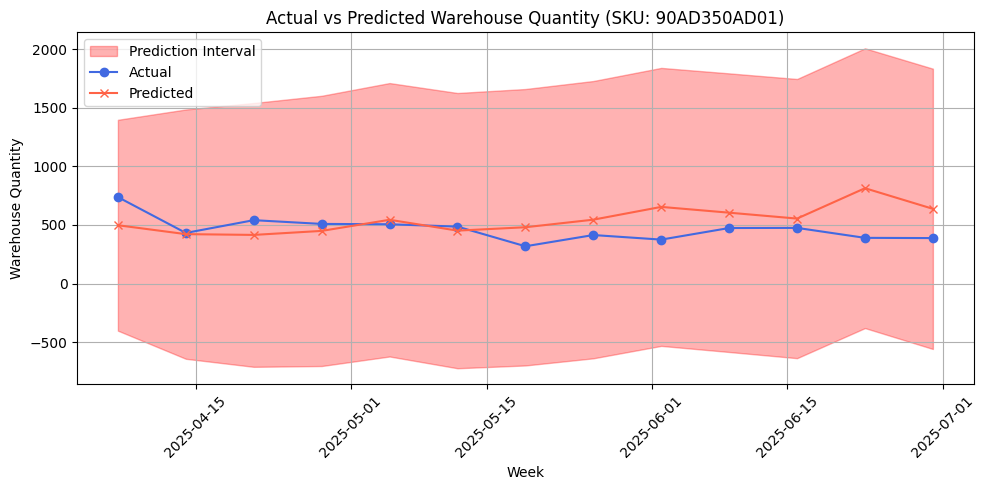


Accuracy within ±10% of predicted values: 23.08%

Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
1950,2025-04-07,2025-04-13,738,498,-240.289953,-32.56%,664,812,Out of Range
1959,2025-04-14,2025-04-20,432,422,-10.326655,-2.39%,389,475,Acceptable
1968,2025-04-21,2025-04-27,541,415,-125.942396,-23.28%,487,595,Out of Range
1978,2025-04-28,2025-05-04,509,449,-59.707315,-11.73%,458,560,Out of Range
1987,2025-05-05,2025-05-11,506,544,38.352556,7.58%,455,557,Acceptable
1996,2025-05-12,2025-05-18,486,452,-34.332661,-7.06%,437,535,Acceptable
2005,2025-05-19,2025-05-25,318,481,162.578059,51.13%,286,350,Out of Range
2016,2025-05-26,2025-06-01,414,545,131.228660,31.7%,373,455,Out of Range
2027,2025-06-02,2025-06-08,375,654,279.289857,74.48%,338,413,Out of Range
2037,2025-06-09,2025-06-15,474,605,130.960575,27.63%,427,521,Out of Range


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare the training series
train_series = train_data.set_index('Week_Start')['WareHouseQuantity'].asfreq('W-MON')

# STEP 2: Fit ARIMA (SARIMAX) Model
# You can tune (p,d,q) as needed
model = SARIMAX(train_series, order=(1,1,1), seasonal_order=(1,1,1,52), enforce_stationarity=False, enforce_invertibility=False)
results = model.fit(disp=False)

# STEP 3: Forecast
n_test = len(test_data)
forecast_result = results.get_forecast(steps=n_test)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# STEP 4: Plot forecast with prediction interval
plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series, label='Train Data', color='black')
plt.plot(test_data['Week_Start'], forecast_mean, label='Forecast', color='blue')
plt.fill_between(test_data['Week_Start'], conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='lightblue', alpha=0.4, label='95% Prediction Interval')
plt.axvline(x=test_start, color='gray', linestyle='--', label='Forecast Start')
plt.title(f"ARIMA Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5: Merge forecast with test data
forecast_df = pd.DataFrame({
    'ds': test_data['Week_Start'],
    'yhat': forecast_mean.values,
    'yhat_lower': conf_int.iloc[:, 0].values,
    'yhat_upper': conf_int.iloc[:, 1].values,
    'WareHouseQuantity': test_data['WareHouseQuantity'].values
})

print("\nForecast vs Actuals (Test Period):")
print(forecast_df[['ds', 'WareHouseQuantity', 'yhat']])

# STEP 6: Evaluation Metrics
y_true = forecast_df['WareHouseQuantity'].values
y_pred = forecast_df['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 7: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(forecast_df['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(forecast_df['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 8: Final Results DataFrame
forecast_df['Start_Week'] = forecast_df['ds']
forecast_df['End_Week'] = forecast_df['Start_Week'] + pd.Timedelta(days=6)
forecast_df['Difference_Between_Predicted_And_Actual'] = forecast_df['yhat'] - forecast_df['WareHouseQuantity']
forecast_df['Percent_Difference'] = (
    forecast_df['Difference_Between_Predicted_And_Actual'] / forecast_df['WareHouseQuantity']
) * 100

forecast_df['Rounded_Predicted'] = forecast_df['yhat'].round().astype(int)
forecast_df['Percent_Difference'] = forecast_df['Percent_Difference'].round(2).astype(str) + '%'

final_result = forecast_df[[
    'Start_Week',
    'End_Week',
    'WareHouseQuantity',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].rename(columns={
    'WareHouseQuantity': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
})

# STEP 9: ±10% Accuracy Evaluation
final_result['Minus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 0.90).round().astype(int)
final_result['Plus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 1.10).round().astype(int)

final_result['Within_10_Percent'] = (
    (final_result['Predicted_WareHouseQuantity'] >= final_result['Minus_10_Percent']) &
    (final_result['Predicted_WareHouseQuantity'] <= final_result['Plus_10_Percent'])
)

final_result['Within_10_Percent'] = final_result['Within_10_Percent'].map({True: 'Acceptable', False: 'Out of Range'})
accuracy_within_10_percent = (final_result['Within_10_Percent'] == 'Acceptable').mean() * 100

print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")
print("\nFinal Forecast Results:")
# print(final_result)

# Optional: Save to CSV
# final_result.to_csv("arima_forecast_results.csv", index=False)
final_result


### ARIMA HyperParameter Tuning

In [27]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Define parameter grid
p = d = q = range(0, 3)  # Non-seasonal parameters
P = D = Q = range(0, 2)  # Seasonal parameters
s = 52  # Weekly data, seasonal cycle of 52 weeks

import itertools
param_grid = list(itertools.product(p, d, q))
seasonal_grid = list(itertools.product(P, D, Q))

# Run grid search
best_score = float("inf")
best_params = None
best_model = None

print("Starting Grid Search for SARIMA Hyperparameters...\n")
for order in param_grid:
    for seasonal_order in seasonal_grid:
        try:
            model = SARIMAX(train_series,
                            order=order,
                            seasonal_order=(seasonal_order[0], seasonal_order[1], seasonal_order[2], s),
                            enforce_stationarity=False,
                            enforce_invertibility=False)
            results = model.fit(disp=False)

            # Choose evaluation metric: AIC or RMSE (here AIC)
            score = results.aic

            if score < best_score:
                best_score = score
                best_params = (order, seasonal_order)
                best_model = results

            print(f"Tested SARIMA{order} x {seasonal_order}52 - AIC: {score:.2f}")

        except Exception as e:
            continue

print("\nBest SARIMA model:")
print(f"Order (p,d,q): {best_params[0]}")
print(f"Seasonal Order (P,D,Q,s): ({best_params[1][0]}, {best_params[1][1]}, {best_params[1][2]}, {s})")
print(f"Best AIC: {best_score:.2f}")


Starting Grid Search for SARIMA Hyperparameters...

Tested SARIMA(0, 0, 0) x (0, 0, 0)52 - AIC: 2097.38
Tested SARIMA(0, 0, 0) x (0, 0, 1)52 - AIC: 1301.13
Tested SARIMA(0, 0, 0) x (0, 1, 0)52 - AIC: 1277.00
Tested SARIMA(0, 0, 0) x (0, 1, 1)52 - AIC: 457.54
Tested SARIMA(0, 0, 0) x (1, 0, 0)52 - AIC: 1293.86
Tested SARIMA(0, 0, 0) x (1, 0, 1)52 - AIC: 1279.50
Tested SARIMA(0, 0, 0) x (1, 1, 0)52 - AIC: 472.56
Tested SARIMA(0, 0, 0) x (1, 1, 1)52 - AIC: 459.54
Tested SARIMA(0, 0, 1) x (0, 0, 0)52 - AIC: 1984.86
Tested SARIMA(0, 0, 1) x (0, 0, 1)52 - AIC: 1224.26
Tested SARIMA(0, 0, 1) x (0, 1, 0)52 - AIC: 1214.26
Tested SARIMA(0, 0, 1) x (0, 1, 1)52 - AIC: 429.46
Tested SARIMA(0, 0, 1) x (1, 0, 0)52 - AIC: 1242.61
Tested SARIMA(0, 0, 1) x (1, 0, 1)52 - AIC: 1211.87
Tested SARIMA(0, 0, 1) x (1, 1, 0)52 - AIC: 459.19
Tested SARIMA(0, 0, 1) x (1, 1, 1)52 - AIC: 431.43
Tested SARIMA(0, 0, 2) x (0, 0, 0)52 - AIC: 1925.05
Tested SARIMA(0, 0, 2) x (0, 0, 1)52 - AIC: 1191.91
Tested SARIMA(0, 0

In [ ]:
# Best SARIMA model:
# Order (p,d,q): (0, 2, 2)
# Seasonal Order (P,D,Q,s): (0, 1, 1, 52)
# Best AIC: 391.57


Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


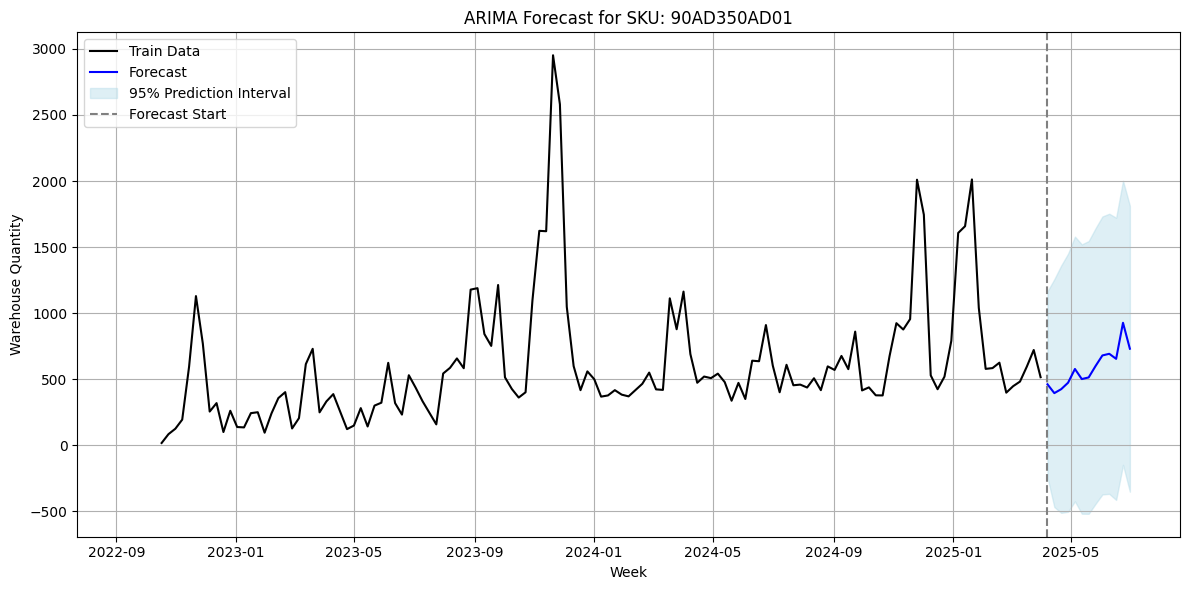


Forecast vs Actuals (Test Period):
             ds  WareHouseQuantity        yhat
1950 2025-04-07                738  461.294668
1959 2025-04-14                432  394.570612
1968 2025-04-21                541  424.538659
1978 2025-04-28                509  473.275249
1987 2025-05-05                506  577.350256
1996 2025-05-12                486  500.968494
2005 2025-05-19                318  513.296052
2016 2025-05-26                414  599.410206
2027 2025-06-02                375  679.695799
2037 2025-06-09                474  692.289652
2047 2025-06-16                475  654.002627
2056 2025-06-23                390  926.934425
2068 2025-06-30                388  730.604669

Accuracy Metrics:
MAE  (Mean Absolute Error):        193.45
MSE  (Mean Squared Error):         57603.62
RMSE (Root Mean Squared Error):    240.01
MAPE (Mean Absolute % Error):      45.31%
R²   (R-squared Score):            -4.78


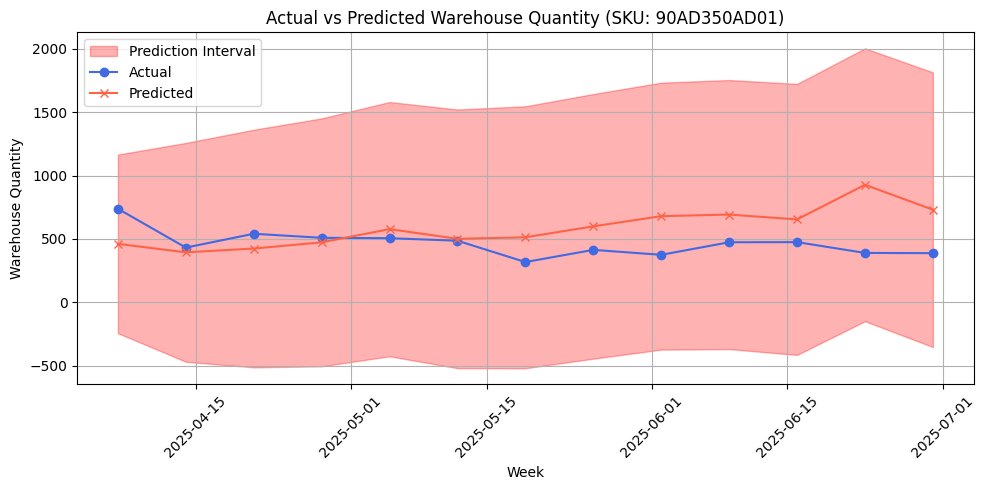


Accuracy within ±10% of predicted values: 23.08%

Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
1950,2025-04-07,2025-04-13,738,461,-276.705332,-37.49%,664,812,Out of Range
1959,2025-04-14,2025-04-20,432,395,-37.429388,-8.66%,389,475,Acceptable
1968,2025-04-21,2025-04-27,541,425,-116.461341,-21.53%,487,595,Out of Range
1978,2025-04-28,2025-05-04,509,473,-35.724751,-7.02%,458,560,Acceptable
1987,2025-05-05,2025-05-11,506,577,71.350256,14.1%,455,557,Out of Range
1996,2025-05-12,2025-05-18,486,501,14.968494,3.08%,437,535,Acceptable
2005,2025-05-19,2025-05-25,318,513,195.296052,61.41%,286,350,Out of Range
2016,2025-05-26,2025-06-01,414,599,185.410206,44.79%,373,455,Out of Range
2027,2025-06-02,2025-06-08,375,680,304.695799,81.25%,338,413,Out of Range
2037,2025-06-09,2025-06-15,474,692,218.289652,46.05%,427,521,Out of Range


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare the training series
train_series = train_data.set_index('Week_Start')['WareHouseQuantity'].asfreq('W-MON')

# STEP 2: Fit ARIMA (SARIMAX) Model
# You can tune (p,d,q) as needed
model = SARIMAX(train_series, order=(1,1,1), seasonal_order=(1,1,1,52), enforce_stationarity=True, enforce_invertibility=True)
results = model.fit(disp=False)

# STEP 3: Forecast
n_test = len(test_data)
forecast_result = results.get_forecast(steps=n_test)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

# STEP 4: Plot forecast with prediction interval
plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series, label='Train Data', color='black')
plt.plot(test_data['Week_Start'], forecast_mean, label='Forecast', color='blue')
plt.fill_between(test_data['Week_Start'], conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='lightblue', alpha=0.4, label='95% Prediction Interval')
plt.axvline(x=test_start, color='gray', linestyle='--', label='Forecast Start')
plt.title(f"ARIMA Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5: Merge forecast with test data
forecast_df = pd.DataFrame({
    'ds': test_data['Week_Start'],
    'yhat': forecast_mean.values,
    'yhat_lower': conf_int.iloc[:, 0].values,
    'yhat_upper': conf_int.iloc[:, 1].values,
    'WareHouseQuantity': test_data['WareHouseQuantity'].values
})

print("\nForecast vs Actuals (Test Period):")
print(forecast_df[['ds', 'WareHouseQuantity', 'yhat']])

# STEP 6: Evaluation Metrics
y_true = forecast_df['WareHouseQuantity'].values
y_pred = forecast_df['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 7: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(forecast_df['ds'], forecast_df['yhat_lower'], forecast_df['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(forecast_df['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(forecast_df['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 8: Final Results DataFrame
forecast_df['Start_Week'] = forecast_df['ds']
forecast_df['End_Week'] = forecast_df['Start_Week'] + pd.Timedelta(days=6)
forecast_df['Difference_Between_Predicted_And_Actual'] = forecast_df['yhat'] - forecast_df['WareHouseQuantity']
forecast_df['Percent_Difference'] = (
    forecast_df['Difference_Between_Predicted_And_Actual'] / forecast_df['WareHouseQuantity']
) * 100

forecast_df['Rounded_Predicted'] = forecast_df['yhat'].round().astype(int)
forecast_df['Percent_Difference'] = forecast_df['Percent_Difference'].round(2).astype(str) + '%'

final_result = forecast_df[[
    'Start_Week',
    'End_Week',
    'WareHouseQuantity',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].rename(columns={
    'WareHouseQuantity': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
})

# STEP 9: ±10% Accuracy Evaluation
final_result['Minus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 0.90).round().astype(int)
final_result['Plus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 1.10).round().astype(int)

final_result['Within_10_Percent'] = (
    (final_result['Predicted_WareHouseQuantity'] >= final_result['Minus_10_Percent']) &
    (final_result['Predicted_WareHouseQuantity'] <= final_result['Plus_10_Percent'])
)

final_result['Within_10_Percent'] = final_result['Within_10_Percent'].map({True: 'Acceptable', False: 'Out of Range'})
accuracy_within_10_percent = (final_result['Within_10_Percent'] == 'Acceptable').mean() * 100

print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")
print("\nFinal Forecast Results:")
# print(final_result)

# Optional: Save to CSV
# final_result.to_csv("arima_forecast_results.csv", index=False)
final_result


In [68]:
test_data.head(-1)

,Week,WareHouseQuantity,Week_Start,Week_End
1950,2025-04-07,738,2025-04-07,2025-04-13
1959,2025-04-14,432,2025-04-14,2025-04-20
1968,2025-04-21,541,2025-04-21,2025-04-27
1978,2025-04-28,509,2025-04-28,2025-05-04
1987,2025-05-05,506,2025-05-05,2025-05-11
1996,2025-05-12,486,2025-05-12,2025-05-18
2005,2025-05-19,318,2025-05-19,2025-05-25
2016,2025-05-26,414,2025-05-26,2025-06-01
2027,2025-06-02,375,2025-06-02,2025-06-08
2037,2025-06-09,474,2025-06-09,2025-06-15


### Linear Regression Forecast


=== Evaluation Metrics ===
MAE  (Mean Absolute Error):        444.21
MSE  (Mean Squared Error):         209547.40
RMSE (Root Mean Squared Error):    457.76
MAPE (Mean Absolute % Error):      103.93%
R²   (R-squared Score):            -20.04

Accuracy within ±10%: 0.00%


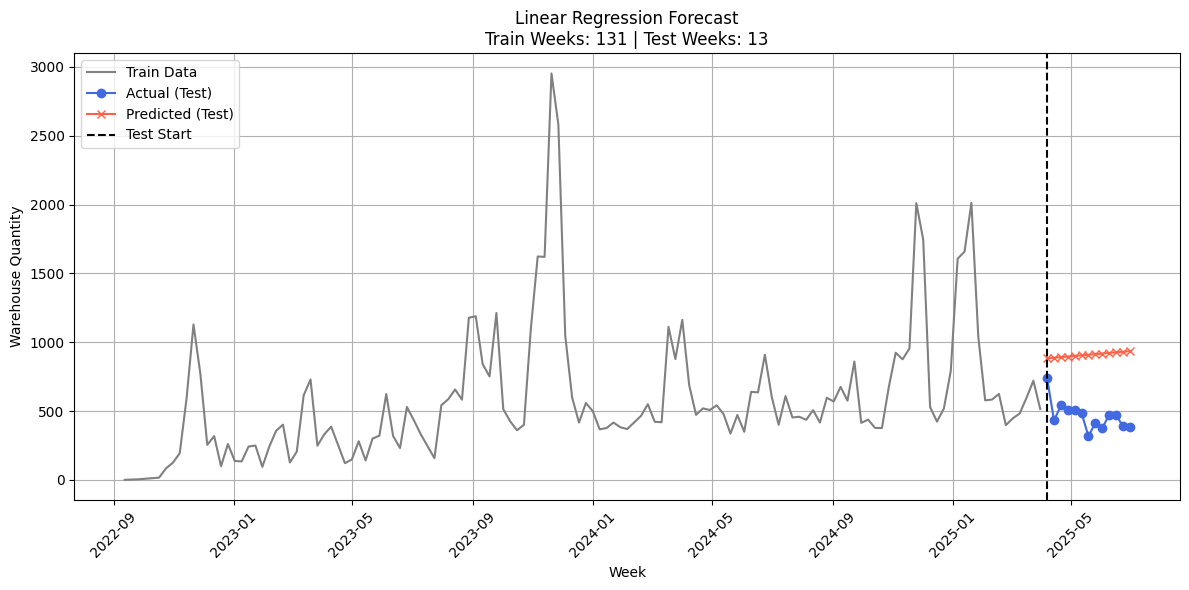


Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738,883,145.408456,19.7%,664,812,Out of Range
1,2025-04-14,2025-04-20,432,888,455.722185,105.49%,389,475,Out of Range
2,2025-04-21,2025-04-27,541,892,351.035915,64.89%,487,595,Out of Range
3,2025-04-28,2025-05-04,509,896,387.349645,76.1%,458,560,Out of Range
4,2025-05-05,2025-05-11,506,901,394.663375,78.0%,455,557,Out of Range
5,2025-05-12,2025-05-18,486,905,418.977105,86.21%,437,535,Out of Range
6,2025-05-19,2025-05-25,318,909,591.290834,185.94%,286,350,Out of Range
7,2025-05-26,2025-06-01,414,914,499.604564,120.68%,373,455,Out of Range
8,2025-06-02,2025-06-08,375,918,542.918294,144.78%,338,413,Out of Range
9,2025-06-09,2025-06-15,474,922,448.232024,94.56%,427,521,Out of Range


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# STEP 0: Prepare Data
# -----------------------------

# Sort data by week
train_data = train_data.sort_values('Week_Start').reset_index(drop=True)
test_data = test_data.sort_values('Week_Start').reset_index(drop=True)

# Add time index for regression
train_data['t'] = np.arange(len(train_data))
test_data['t'] = np.arange(len(train_data), len(train_data) + len(test_data))

# -----------------------------
# STEP 1: Train Linear Regression Model
# -----------------------------
X_train = train_data[['t']]
y_train = train_data['WareHouseQuantity']

model = LinearRegression()
model.fit(X_train, y_train)

# -----------------------------
# STEP 2: Predict on Test Data
# -----------------------------
X_test = test_data[['t']]
test_data['Predicted_WareHouseQuantity'] = model.predict(X_test)

# -----------------------------
# STEP 3: Evaluation Metrics
# -----------------------------
y_true = test_data['WareHouseQuantity'].values
y_pred = test_data['Predicted_WareHouseQuantity'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print("\n=== Evaluation Metrics ===")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# -----------------------------
# STEP 4: Accuracy within ±10%
# -----------------------------
final_result = test_data.copy()
final_result['Difference_Between_Predicted_And_Actual'] = final_result['Predicted_WareHouseQuantity'] - final_result['WareHouseQuantity']
final_result['Percent_Difference'] = ((final_result['Difference_Between_Predicted_And_Actual']) / final_result['WareHouseQuantity']) * 100

final_result['Minus_10_Percent'] = (final_result['WareHouseQuantity'] * 0.90).round().astype(int)
final_result['Plus_10_Percent'] = (final_result['WareHouseQuantity'] * 1.10).round().astype(int)

final_result['Within_10_Percent'] = (
    (final_result['Predicted_WareHouseQuantity'] >= final_result['Minus_10_Percent']) &
    (final_result['Predicted_WareHouseQuantity'] <= final_result['Plus_10_Percent'])
)
final_result['Within_10_Percent'] = final_result['Within_10_Percent'].map({True: 'Acceptable', False: 'Out of Range'})

accuracy_within_10_percent = (final_result['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10%: {accuracy_within_10_percent:.2f}%")

# -----------------------------
# STEP 5: Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(train_data['Week_Start'], train_data['WareHouseQuantity'], label='Train Data', color='gray')
plt.plot(test_data['Week_Start'], test_data['WareHouseQuantity'], label='Actual (Test)', marker='o', color='royalblue')
plt.plot(test_data['Week_Start'], test_data['Predicted_WareHouseQuantity'], label='Predicted (Test)', marker='x', color='tomato')
plt.axvline(x=test_data['Week_Start'].min(), color='black', linestyle='--', label='Test Start')
plt.title(f"Linear Regression Forecast\nTrain Weeks: {len(train_data)} | Test Weeks: {len(test_data)}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# STEP 6: Final Output Format
# -----------------------------
final_result['Start_Week'] = final_result['Week_Start']
final_result['End_Week'] = final_result['Start_Week'] + pd.Timedelta(days=6)

final_result['Rounded_Predicted'] = final_result['Predicted_WareHouseQuantity'].round().astype(int)
final_result['Percent_Difference'] = final_result['Percent_Difference'].round(2).astype(str) + '%'

# Final columns
final_result = final_result[[
    'Start_Week',
    'End_Week',
    'WareHouseQuantity',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference',
    'Minus_10_Percent',
    'Plus_10_Percent',
    'Within_10_Percent'
]]

final_result.rename(columns={
    'WareHouseQuantity': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
}, inplace=True)

# Optional: Save results
# final_result.to_csv("linear_regression_forecast_results.csv", index=False)

# Display results
print("\nFinal Forecast Results:")
final_result


### Using Polynomial Regression for SKU Forecasting

Degree 1: RMSE = 457.76
Degree 2: RMSE = 251.19
Degree 3: RMSE = 422.18
Degree 4: RMSE = 667.26
Degree 5: RMSE = 719.19

Best Polynomial Degree: 2

=== Evaluation Metrics ===
MAE  (Mean Absolute Error):        236.48
MSE  (Mean Squared Error):         63097.14
RMSE (Root Mean Squared Error):    251.19
MAPE (Mean Absolute % Error):      56.47%
R²   (R-squared Score):            -5.33

Accuracy within ±10%: 7.69%


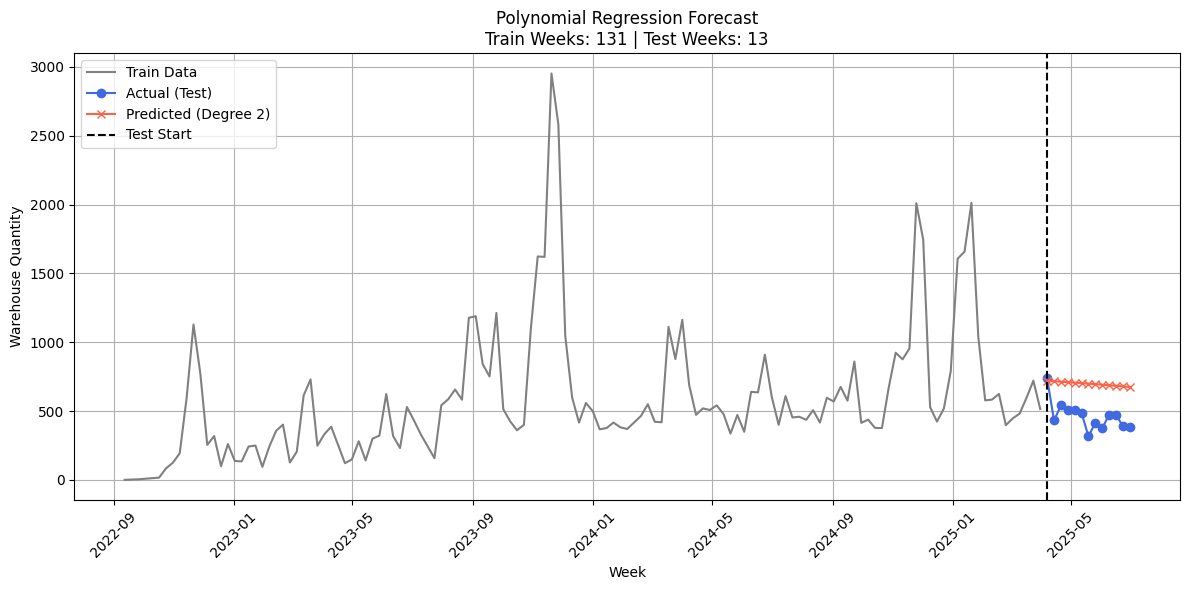


Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,2025-04-07,2025-04-13,738,720,-18.058900,-2.45%,664,812,Acceptable
1,2025-04-14,2025-04-20,432,717,284.824495,65.93%,389,475,Out of Range
2,2025-04-21,2025-04-27,541,714,172.596156,31.9%,487,595,Out of Range
3,2025-04-28,2025-05-04,509,710,201.256083,39.54%,458,560,Out of Range
4,2025-05-05,2025-05-11,506,707,200.804275,39.68%,455,557,Out of Range
5,2025-05-12,2025-05-18,486,703,217.240733,44.7%,437,535,Out of Range
6,2025-05-19,2025-05-25,318,700,381.565457,119.99%,286,350,Out of Range
7,2025-05-26,2025-06-01,414,696,281.778446,68.06%,373,455,Out of Range
8,2025-06-02,2025-06-08,375,692,316.879701,84.5%,338,413,Out of Range
9,2025-06-09,2025-06-15,474,688,213.869222,45.12%,427,521,Out of Range


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# STEP 0: Prepare Data
# -----------------------------

# Ensure your data is already split into train_data and test_data
train_data = train_data.sort_values('Week_Start').reset_index(drop=True)
test_data = test_data.sort_values('Week_Start').reset_index(drop=True)

# Add time index for regression
train_data['t'] = np.arange(len(train_data))
test_data['t'] = np.arange(len(train_data), len(train_data) + len(test_data))

X_train = train_data[['t']]
y_train = train_data['WareHouseQuantity']
X_test = test_data[['t']]
y_true = test_data['WareHouseQuantity'].values

# -----------------------------
# STEP 1: Polynomial Regression Tuning
# -----------------------------
best_rmse = float('inf')
best_degree = None
best_model = None

for degree in range(1, 6):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"Degree {degree}: RMSE = {rmse:.2f}")
    
    if rmse < best_rmse:
        best_rmse = rmse
        best_degree = degree
        best_model = model
        best_predictions = y_pred

print(f"\nBest Polynomial Degree: {best_degree}")

# -----------------------------
# STEP 2: Predict on Test Data
# -----------------------------
test_data['Predicted_WareHouseQuantity'] = best_predictions

# -----------------------------
# STEP 3: Evaluation Metrics
# -----------------------------
mae = mean_absolute_error(y_true, best_predictions)
mse = mean_squared_error(y_true, best_predictions)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - best_predictions) / y_true)) * 100
r2 = r2_score(y_true, best_predictions)

print("\n=== Evaluation Metrics ===")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# -----------------------------
# STEP 4: Accuracy within ±10%
# -----------------------------
final_result = test_data.copy()
final_result['Difference_Between_Predicted_And_Actual'] = final_result['Predicted_WareHouseQuantity'] - final_result['WareHouseQuantity']
final_result['Percent_Difference'] = ((final_result['Difference_Between_Predicted_And_Actual']) / final_result['WareHouseQuantity']) * 100

final_result['Minus_10_Percent'] = (final_result['WareHouseQuantity'] * 0.90).round().astype(int)
final_result['Plus_10_Percent'] = (final_result['WareHouseQuantity'] * 1.10).round().astype(int)

final_result['Within_10_Percent'] = (
    (final_result['Predicted_WareHouseQuantity'] >= final_result['Minus_10_Percent']) &
    (final_result['Predicted_WareHouseQuantity'] <= final_result['Plus_10_Percent'])
)
final_result['Within_10_Percent'] = final_result['Within_10_Percent'].map({True: 'Acceptable', False: 'Out of Range'})

accuracy_within_10_percent = (final_result['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10%: {accuracy_within_10_percent:.2f}%")

# -----------------------------
# STEP 5: Plot Actual vs Predicted
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(train_data['Week_Start'], train_data['WareHouseQuantity'], label='Train Data', color='gray')
plt.plot(test_data['Week_Start'], test_data['WareHouseQuantity'], label='Actual (Test)', marker='o', color='royalblue')
plt.plot(test_data['Week_Start'], test_data['Predicted_WareHouseQuantity'], label=f'Predicted (Degree {best_degree})', marker='x', color='tomato')
plt.axvline(x=test_data['Week_Start'].min(), color='black', linestyle='--', label='Test Start')
plt.title(f"Polynomial Regression Forecast\nTrain Weeks: {len(train_data)} | Test Weeks: {len(test_data)}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# STEP 6: Final Output Format
# -----------------------------
final_result['Start_Week'] = final_result['Week_Start']
final_result['End_Week'] = final_result['Start_Week'] + pd.Timedelta(days=6)
final_result['Rounded_Predicted'] = final_result['Predicted_WareHouseQuantity'].round().astype(int)
final_result['Percent_Difference'] = final_result['Percent_Difference'].round(2).astype(str) + '%'

final_result = final_result[[
    'Start_Week',
    'End_Week',
    'WareHouseQuantity',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference',
    'Minus_10_Percent',
    'Plus_10_Percent',
    'Within_10_Percent'
]]

final_result.rename(columns={
    'WareHouseQuantity': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
}, inplace=True)

# Optional: Save results
# final_result.to_csv("polynomial_regression_forecast_results.csv", index=False)

# Display final results
print("\nFinal Forecast Results:")
final_result


11:03:21 - cmdstanpy - INFO - Chain [1] start processing



Training Data Range: 2022-09-12 to 2025-03-31
 - Total Years:  4
 - Total Months: 31
 - Total Weeks:  131

Testing Data Range:  2025-04-07 to 2025-06-30
 - Total Years:  1
 - Total Months: 3
 - Total Weeks:  13


11:03:21 - cmdstanpy - INFO - Chain [1] done processing


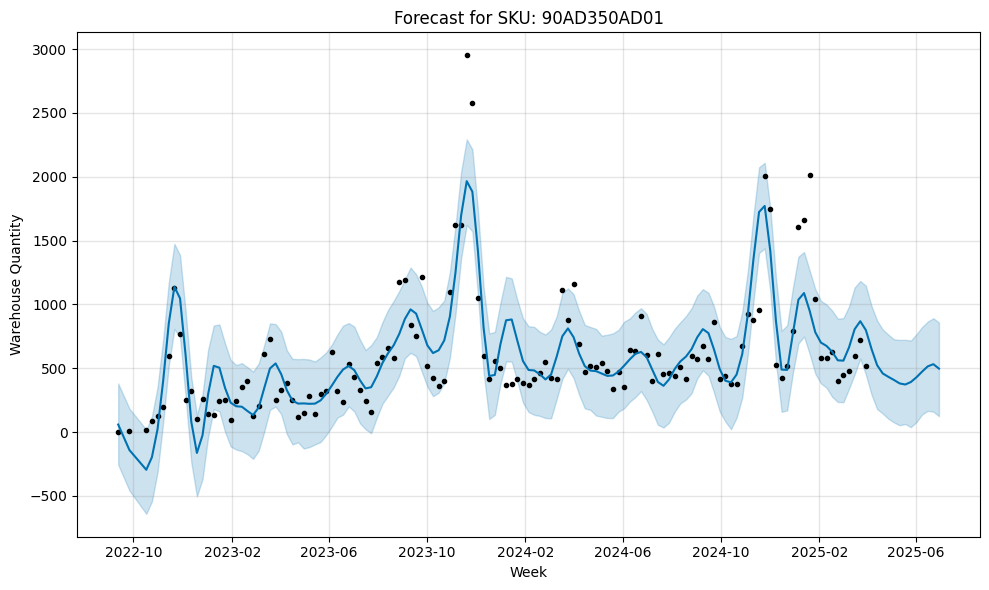

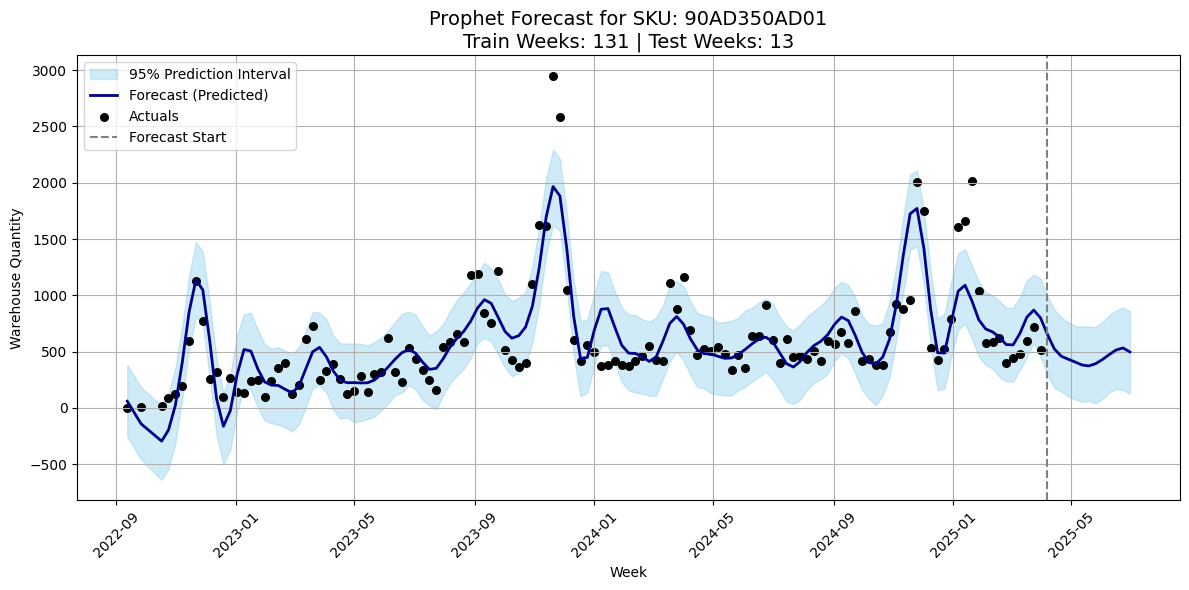


Forecast vs Actuals (Test Period):
            ds  WareHouseQuantity        yhat
131 2025-04-07              738.0  651.795211
132 2025-04-14              432.0  524.103811
133 2025-04-21              541.0  459.156536
134 2025-04-28              509.0  432.769425
135 2025-05-05              506.0  408.027363
136 2025-05-12              486.0  381.333974
137 2025-05-19              318.0  372.684672
138 2025-05-26              414.0  391.943756
139 2025-06-02              375.0  429.402024
140 2025-06-09              474.0  473.560427
141 2025-06-16              475.0  514.514797
142 2025-06-23              390.0  531.969645
143 2025-06-30              388.0  497.193854

Accuracy Metrics:
MAE  (Mean Absolute Error):        73.94
MSE  (Mean Squared Error):         6850.32
RMSE (Root Mean Squared Error):    82.77
MAPE (Mean Absolute % Error):      16.46%
R²   (R-squared Score):            0.31


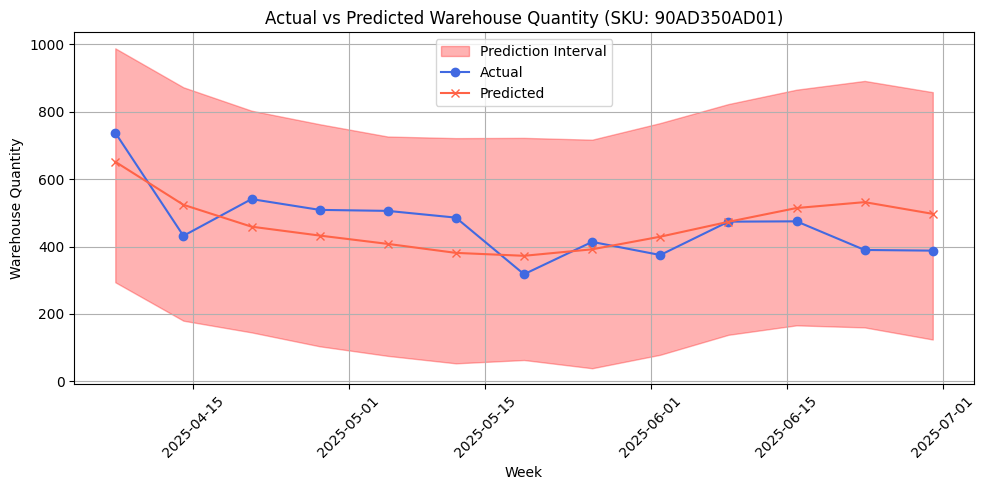


Accuracy within ±10% of predicted values: 23.08%

Final Forecast Results:


,Start_Week,End_Week,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
131,2025-04-07,2025-04-13,738.0,652,-86.204789,-11.68%,664,812,Out of Range
132,2025-04-14,2025-04-20,432.0,524,92.103811,21.32%,389,475,Out of Range
133,2025-04-21,2025-04-27,541.0,459,-81.843464,-15.13%,487,595,Out of Range
134,2025-04-28,2025-05-04,509.0,433,-76.230575,-14.98%,458,560,Out of Range
135,2025-05-05,2025-05-11,506.0,408,-97.972637,-19.36%,455,557,Out of Range
136,2025-05-12,2025-05-18,486.0,381,-104.666026,-21.54%,437,535,Out of Range
137,2025-05-19,2025-05-25,318.0,373,54.684672,17.2%,286,350,Out of Range
138,2025-05-26,2025-06-01,414.0,392,-22.056244,-5.33%,373,455,Acceptable
139,2025-06-02,2025-06-08,375.0,429,54.402024,14.51%,338,413,Out of Range
140,2025-06-09,2025-06-15,474.0,474,-0.439573,-0.09%,427,521,Acceptable


In [34]:
from prophet import Prophet
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd

# STEP 0: Print Training & Testing Period Info
train_start = train_data['Week_Start'].min()
train_end = train_data['Week_Start'].max()
test_start = test_data['Week_Start'].min()
test_end = test_data['Week_Start'].max()

# Compute durations
train_months = (train_end.to_period('M') - train_start.to_period('M')).n + 1
train_years = (train_end.to_period('Y') - train_start.to_period('Y')).n + 1
train_weeks = train_data['Week_Start'].nunique()

test_months = (test_end.to_period('M') - test_start.to_period('M')).n + 1
test_years = (test_end.to_period('Y') - test_start.to_period('Y')).n + 1
test_weeks = test_data['Week_Start'].nunique()

print(f"\nTraining Data Range: {train_start.date()} to {train_end.date()}")
print(f" - Total Years:  {train_years}")
print(f" - Total Months: {train_months}")
print(f" - Total Weeks:  {train_weeks}")

print(f"\nTesting Data Range:  {test_start.date()} to {test_end.date()}")
print(f" - Total Years:  {test_years}")
print(f" - Total Months: {test_months}")
print(f" - Total Weeks:  {test_weeks}")

# STEP 1: Prepare train data for Prophet
prophet_df = train_data[['Week_Start', 'WareHouseQuantity']].rename(
    columns={'Week_Start': 'ds', 'WareHouseQuantity': 'y'}
)

# STEP 2: Initialize and fit the model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=1.0,
    seasonality_prior_scale=5.0,
    holidays_prior_scale=0.00801378512898308
)
model.add_country_holidays(country_name='US')
model.fit(prophet_df)

# STEP 3: Create future dataframe covering test period
future_weeks = model.make_future_dataframe(periods=len(test_data), freq='W-MON')

# STEP 4: Predict
forecast = model.predict(future_weeks)

# STEP 5: Plot forecast with prediction interval
fig = model.plot(forecast)
plt.title(f"Forecast for SKU: {sku}")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 5 (Enhanced Visualization)
historical = prophet_df.copy()
historical['label'] = 'Actuals'
forecast_plot = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_plot['label'] = 'Forecast'

plt.figure(figsize=(12, 6))
plt.fill_between(forecast_plot['ds'], forecast_plot['yhat_lower'], forecast_plot['yhat_upper'],
                 color='skyblue', alpha=0.4, label='95% Prediction Interval')
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], color='darkblue', label='Forecast (Predicted)', linewidth=2)
plt.scatter(historical['ds'], historical['y'], color='black', label='Actuals', s=30)

test_boundary = test_data['Week_Start'].min()
plt.axvline(x=test_boundary, color='gray', linestyle='--', label='Forecast Start')

plt.title(f"Prophet Forecast for SKU: {sku}\nTrain Weeks: {train_weeks} | Test Weeks: {test_weeks}", fontsize=14)
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 6: Merge actual test data
forecast_df = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
forecast_df = forecast_df.merge(
    test_data[['Week_Start', 'WareHouseQuantity']],
    left_on='ds', right_on='Week_Start', how='left'
)

# Display forecast vs actuals
print("\nForecast vs Actuals (Test Period):")
print(forecast_df[forecast_df['Week_Start'].notna()][['ds', 'WareHouseQuantity', 'yhat']])

# STEP 7: Evaluation Metrics
test_forecast = forecast_df[forecast_df['Week_Start'].notna()].copy()
test_forecast.rename(columns={
    'WareHouseQuantity': 'actual',
    'yhat': 'predicted'
}, inplace=True)
test_forecast.dropna(subset=['actual', 'predicted'], inplace=True)

y_true = test_forecast['actual'].values
y_pred = test_forecast['predicted'].values

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
r2 = r2_score(y_true, y_pred)

print(f"\nAccuracy Metrics:")
print(f"MAE  (Mean Absolute Error):        {mae:.2f}")
print(f"MSE  (Mean Squared Error):         {mse:.2f}")
print(f"RMSE (Root Mean Squared Error):    {rmse:.2f}")
print(f"MAPE (Mean Absolute % Error):      {mape:.2f}%")
print(f"R²   (R-squared Score):            {r2:.2f}")

# STEP 8: Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.fill_between(test_forecast['ds'],
                 test_forecast['yhat_lower'],
                 test_forecast['yhat_upper'],
                 alpha=0.3, color='red', label='Prediction Interval')
plt.plot(test_forecast['ds'], y_true, marker='o', label='Actual', color='royalblue')
plt.plot(test_forecast['ds'], y_pred, marker='x', label='Predicted', color='tomato')
plt.title(f"Actual vs Predicted Warehouse Quantity (SKU: {sku})")
plt.xlabel("Week")
plt.ylabel("Warehouse Quantity")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# STEP 9: Final Results DataFrame
test_forecast['Start_Week'] = test_forecast['ds']
test_forecast['End_Week'] = test_forecast['Start_Week'] + pd.Timedelta(days=6)
test_forecast['Difference_Between_Predicted_And_Actual'] = test_forecast['predicted'] - test_forecast['actual']
test_forecast['Percent_Difference'] = (
    test_forecast['Difference_Between_Predicted_And_Actual'] / test_forecast['actual']
) * 100

# Round predicted values for display only
test_forecast['Rounded_Predicted'] = test_forecast['predicted'].round().astype(int)
test_forecast['Percent_Difference'] = test_forecast['Percent_Difference'].round(2).astype(str) + '%'

# Final presentation DataFrame
final_result = test_forecast[[
    'Start_Week',
    'End_Week',
    'actual',
    'Rounded_Predicted',
    'Difference_Between_Predicted_And_Actual',
    'Percent_Difference'
]].copy()

final_result.rename(columns={
    'actual': 'Actual_WareHouseQuantity',
    'Rounded_Predicted': 'Predicted_WareHouseQuantity'
}, inplace=True)

# STEP 10: ±10% Accuracy Evaluation
final_result['Minus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 0.90).round().astype(int)
final_result['Plus_10_Percent'] = (final_result['Actual_WareHouseQuantity'] * 1.10).round().astype(int)

final_result['Within_10_Percent'] = (
    (final_result['Predicted_WareHouseQuantity'] >= final_result['Minus_10_Percent']) &
    (final_result['Predicted_WareHouseQuantity'] <= final_result['Plus_10_Percent'])
)

# Convert to readable format
final_result['Within_10_Percent'] = final_result['Within_10_Percent'].map({True: 'Acceptable', False: 'Out of Range'})

# Accuracy within ±10% band
accuracy_within_10_percent = (final_result['Within_10_Percent'] == 'Acceptable').mean() * 100
print(f"\nAccuracy within ±10% of predicted values: {accuracy_within_10_percent:.2f}%")

# Display final results
print("\nFinal Forecast Results:")
# print(final_result)

# Optional: Save to CSV
# final_result.to_csv("forecast_results_with_10_percent_band.csv", index=False)
final_result
